# Detection of Spatial Signatures in Medellin

This notebook contains complete code required for a detection of spatial signatures in Medellin, limited by its administrative boundary.

This notebook relies on the `gds_env` as its main computational engine, which is deployed on a variety of servers and setups. This means that all the code produced in the project is reproducible under the containers provided in `gds_env`. This notebook uses `gds_py` flavour in a version `6.0`.

For more information on how to run `gds_env`, please visit:

> https://darribas.org/gds_env/

## Contents
- 1. Analysis of form
    - 1.1. Data retrieval and pre-processing
        - 1.1.1. Bulding footprints
        - 1.1.2. Case study area
        - 1.1.3. Street network
        - 1.1.4. Spatial barriers
    - 1.2. Generation of geographies
        - 1.3.1. Enclosures
        - 1.3.2. Enlclosed tessellation
    - 1.3. Morphometric analysis
        - 1.4.1. Primary morphometric characters
        - 1.4.2. Contextualisation
- 2. Analysis of function
    - 2.1. Trees
    - 2.2. Green areas
    - 2.3. Heritage
    - 2.4. Land use
    - 2.5. POIs
    - 2.6. Public spaces
    - 2.7. Industry and commerce
    - 2.8. Population
    - 2.9. NDVI
- 3. Cluster analysis
    - 3.1. Form
    - 3.2. Function
    - 3.3. Spatial Signatures
- 4. Figures
- 5. Cluster summary

All packages and custom modules are imported below.

In [1]:
import pickle

import dask_geopandas
import geopandas as gpd
import libpysal
import momepy
import numpy as np
import osmnx as ox
import pandana
import pandas as pd
import rasterstats
import requests
import rioxarray
import scipy
import utils
import utils.momepy
import utils.tobler
import xarray

from clustergram import Clustergram
from dask.distributed import Client, LocalCluster
from download import download
from shapely.geometry import box
from sklearn import preprocessing
from sklearn.cluster import KMeans
from tqdm import tqdm
from utils.dask_geopandas import dask_dissolve

import urbangrammar_graphics as ugg
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily

First we specify a path to a folder for a data storage.

In [2]:
folder = "../../urbangrammar_samba/sp_sig_concept/medellin/"

## 1. Analysis of form

First step towards spatial signtures is an analysis of urban form to capture its patterns.

### 1.1. Data retrieval

All data used in the work are obtained from open access sources.

#### 1.1.1 Building footprints

Building footprints are obtained from [Medellin open data portal](https://www.medellin.gov.co/geomedellin/#divOpenData). However, we footprints of individual buildings are often split into mupliple polygons. To get cleaner version of polygons, we use plot layer to join together adjacent polygons on the same plot.

First we download buildings.

In [19]:
path = folder + "buildings"
blg = download("https://opendata.arcgis.com/datasets/7e7cd8414e7f456cb3605b7f461d4aa0_5.zip", path, kind="zip")

Creating data folder...

file_sizes: 150MB [00:05, 28.4MB/s]                                             
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/buildings


Then we download plots/lots.

In [20]:
path = folder + "lots"
lots = download("https://opendata.arcgis.com/datasets/040e022660b14622a072915530f93cf9_8.zip", path, kind="zip")

Creating data folder...

file_sizes: 92.8MB [00:03, 30.6MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/lots


Now we can open both as GeoDataFrames.

In [35]:
buildings = gpd.read_file(blg)

In [22]:
plots = gpd.read_file(lots)

For clarity, we rename a column containing number of floors to english.

In [36]:
buildings = buildings[["NUMERO_PIS", "geometry"]].rename(columns={"NUMERO_PIS": "n_floors"})

We use representative point of each polygon to perform the spatial join with plots. 

In [37]:
buildings["point"] = buildings.representative_point()
buildings = buildings.set_geometry("point")

In [38]:
%time join = gpd.sjoin(buildings, plots[["geometry"]], how="left")

CPU times: user 34.6 s, sys: 0 ns, total: 34.6 s
Wall time: 34.6 s


In [39]:
join.head(10)

,n_floors,geometry,point,index_right
0,2,"POLYGON ((-75.54168 6.29355, -75.54164 6.29349...",POINT (-75.54171 6.29353),182749.0
1,1,"POLYGON ((-75.54163 6.29348, -75.54162 6.29341...",POINT (-75.54163 6.29345),NaN
2,2,"POLYGON ((-75.54188 6.29348, -75.54188 6.29348...",POINT (-75.54188 6.29342),NaN
3,2,"POLYGON ((-75.54182 6.29289, -75.54186 6.29267...",POINT (-75.54195 6.29275),277957.0
4,1,"POLYGON ((-75.54278 6.29732, -75.54280 6.29730...",POINT (-75.54280 6.29732),198347.0
5,1,"POLYGON ((-75.54375 6.30094, -75.54373 6.30094...",POINT (-75.54371 6.30092),208626.0
6,1,"POLYGON ((-75.54272 6.30088, -75.54274 6.30083...",POINT (-75.54277 6.30089),180661.0
7,1,"POLYGON ((-75.54394 6.30074, -75.54396 6.30071...",POINT (-75.54398 6.30074),276046.0
8,1,"POLYGON ((-75.54403 6.30072, -75.54399 6.30068...",POINT (-75.54403 6.30065),208629.0
9,2,"POLYGON ((-75.54414 6.30064, -75.54410 6.30061...",POINT (-75.54413 6.30061),180257.0


Now we can clean the resultng data frame and dissolve polygons based on plot index.

In [41]:
join_notna = join[~join.index_right.isna()]

In [42]:
%%time
dissolved = join_notna.set_geometry("geometry").drop(columns="point").dissolve("index_right", aggfunc='median')

CPU times: user 1min 22s, sys: 0 ns, total: 1min 22s
Wall time: 1min 22s


We don't need `index_right` anymore.

In [60]:
buildings = dissolved.reset_index().drop(columns="index_right")

To get single-part polygons, we explode the non-null result.

In [61]:
buildings = buildings[~buildings.geometry.isna()].explode().reset_index(drop=True)

Some small buildings do not have assigned number of floors, so we replace zeros with one. Later we can decide if we use them or not.

In [62]:
buildings = buildings.replace({0.0: 1, 0.5: 1})

We reset index, assing unique ID and make sure each polygon is valid and our data are in the right projection.

In [63]:
buildings = buildings.reset_index(drop=True)
buildings['uID'] = range(len(buildings))
buildings["geometry"] = buildings.geometry.buffer(0)

In [64]:
buildings.geom_type.value_counts()

Polygon    338181
dtype: int64

In [14]:
buildings = buildings.to_crs(3117)

We can now save processed buildings to a file.

In [65]:
buildings.to_parquet(folder + "buildings.pq")

<ipython-input-65-0929575016ac>:1: UserWarning: this is an initial implementation of Parquet/Feather file support and associated metadata.  This is tracking version 0.1.0 of the metadata specification at https://github.com/geopandas/geo-arrow-spec

This metadata specification does not yet make stability promises.  We do not yet recommend using this in a production setting unless you are able to rewrite your Parquet/Feather files.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', message='.*initial implementation of Parquet.*')
  buildings.to_parquet("../../urbangrammar_samba/sp_sig_concept/medellin/buildings.pq")


#### 1.1.2 Case study area

Case study area is the administrative limit of the city available on open data portal.

In [68]:
path = folder + "limits"
download("https://opendata.arcgis.com/datasets/283d1d14584641c9971edbd2f695e502_6.zip", path, kind="zip")

Creating data folder...

file_sizes: 1.07MB [00:00, 2.37MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/limits


'../../urbangrammar_samba/sp_sig_concept/medellin/limits'

We want a single polygon denoting the study area, so we dissolve the data to a one geometry.

In [2]:
limits = gpd.read_file(folder + "limits")
polygon = limits.unary_union

#### 1.1.3 Street network

Street network is obtined from OSM using OSMnx, custom tags and a polygon.

We get a graph, project it, turn into undirected one and export to GeoDataFrame. Then we make sure `highway` parameter is string and can be saved to file.

In [ ]:
type_filter = '["highway"~"living_street|motorway|motorway_link|pedestrian|primary|primary_link|residential|secondary|secondary_link|service|tertiary|tertiary_link|trunk|trunk_link"]'

streets_graph = ox.graph_from_polygon(polygon, network_type='all_private', custom_filter=type_filter, retain_all=True)
streets_graph = ox.projection.project_graph(streets_graph)
gdf = ox.graph_to_gdfs(ox.get_undirected(streets_graph), nodes=False, edges=True, node_geometry=False, fill_edge_geometry=True)
gdf.highway = gdf.highway.astype(str)
path = folder + 'roads_osm.pq'
gdf[['highway', 'geometry']].to_parquet(path)

#### 1.1.3. Spatial barriers

Identification of enclosures should optimally contain variety of barriers, not only street networks. Therefore, we download railway and water geometry from OSM. We can filter the required data by the the polygon.

##### Water

In [ ]:
tags = {'natural': ['water', 'coastline', 'spring']}
gdf = ox.geometries_from_polygon(polygon, tags)
path = folder + 'water_osm.pq'
gdf[['natural', 'geometry']].to_parquet(path)

##### Railway

Then we get railway and filter out proper geometry type (we want LineStrings representing railway tracks) and remove tunnels (those are not spatial barriers).

In [ ]:
tags = {'railway': True}
gdf = ox.geometries_from_polygon(polygon, tags)
gdf = gdf[gdf.geom_type == 'LineString']
gdf = gdf[gdf.tunnel != 'yes']
path = folder + 'railway_osm.pq'
gdf[['railway', 'geometry']].to_parquet(path)

Let's now reproject, check our barriers and close potential unwanted gaps to generate clean enclosures

In [3]:
roads = gpd.read_parquet(folder + 'roads_osm.pq').to_crs(3117)

In [84]:
roads.geom_type.value_counts()

LineString    27725
dtype: int64

In [4]:
railway = gpd.read_parquet(folder + 'railway_osm.pq').to_crs(3117)

In [86]:
railway.geom_type.unique()

array(['LineString'], dtype=object)

Roads seems to be fine, similarly to railway. The only step we do is extension of railway lines to snap to roads.

In [5]:
extended_railway = utils.momepy.extend_lines(railway, 30, target=roads, extension=.1)

In [6]:
water = gpd.read_parquet(folder + "water_osm.pq").to_crs(3117)

In [7]:
water.geom_type.value_counts()

Polygon    65
Point       1
dtype: int64

For water, we keep only polygons.

In [8]:
water = water[water.geom_type == "Polygon"]
water.geometry = water.geometry.boundary

### 1.2. Generation of geographies

Now we have to create geographies we will be using in the analysis. Enclosures and enclosed tessellation.

#### 1.2.1. Enclosures

Enclosures require spatial barriers, which are roads and railway (we use the extended one we did above) and water, limited by administrative boundary.

In [9]:
limit = limits.to_crs(3117)

In [10]:
%%time
enclosures = utils.momepy.enclosures(roads, limit=limit, additional_barriers=[extended_railway, water])

CPU times: user 2.36 s, sys: 71.1 ms, total: 2.43 s
Wall time: 2.39 s


In [ ]:
enclosures.to_parquet(folder + "enclosures.pq")

#### 1.3.2. Enclosed tessellation

With enclosures and buildings, we can now create enclosed tessellation. To have a better control of dask cluster, we can create it directly (enclosed tessellation is a dask-parallelised function).

In [12]:
client = Client(LocalCluster(n_workers=16))
client

Client Scheduler: tcp://127.0.0.1:41457 Dashboard: http://127.0.0.1:8787/status,Cluster Workers: 16 Cores: 16 Memory: 134.91 GB


In [13]:
buildings = gpd.read_parquet(folder + "buildings.pq")

In [18]:
%%time
tess = utils.momepy.Tessellation(buildings, 'uID', enclosures=enclosures)

/opt/conda/lib/python3.8/site-packages/distributed/worker.py:3373: UserWarning: Large object of size 105.07 MB detected in task graph: 
  ([         eID                                     ...  0.05, 'uID'],)
Consider scattering large objects ahead of time
with client.scatter to reduce scheduler burden and 
keep data on workers

    future = client.submit(func, big_data)    # bad

    big_future = client.scatter(big_data)     # good
    future = client.submit(func, big_future)  # good
  warnings.warn(


CPU times: user 1min 15s, sys: 9.17 s, total: 1min 24s
Wall time: 8min 46s


In [19]:
tessellation = tess.tessellation

Now we can assign unique ID to each tessellation cell and save them. 

In [ ]:
tessellation['tID'] = range(len(tessellation))
tessellation.to_parquet(folder + "tessellation.pq")

### 1.3. Morphometric analysis

Morpohmetric analysis first measures primary characters, which are then contextualised to capture the tendencies within the local context of each tessellation cell.

#### 1.3.1. Primary morphometric characters

For the analysis we need four input layer representing urban form - buildings, streets, enclosed tessellation and enclosures.

In [21]:
tess = gpd.read_parquet(folder + "tessellation.pq")
blg = gpd.read_parquet(folder + "buildings.pq")
streets = gpd.read_parquet(folder + 'roads_osm.pq').to_crs(3117)
enclosures = gpd.read_parquet(folder + "enclosures.pq")

In [22]:
tess.crs == blg.crs == streets.crs == enclosures.crs

True

In many cases, we will need to relate buildings to tessellation cells. the best way to ensure the proper linkage is to combine both GeoDataFrames into a single one with two named geometry columns. Remember that not every cell has assigned a building.

In [23]:
tess = tess.rename_geometry("tessellation").merge(blg[['uID', 'geometry']].rename_geometry("buildings"), on='uID', how='left')

In [24]:
tess

,uID,tessellation,eID,tID,buildings
0,93762.0,"POLYGON ((502018.719 1180644.567, 502018.955 1...",0,0,"POLYGON ((502021.345 1180673.678, 502020.037 1..."
1,93763.0,"POLYGON ((502020.261 1180663.879, 502019.824 1...",0,1,"POLYGON ((502022.735 1180667.440, 502021.533 1..."
2,93773.0,"POLYGON ((502065.088 1180656.807, 502065.010 1...",0,2,"POLYGON ((502065.089 1180661.593, 502063.187 1..."
3,108053.0,"POLYGON ((502030.501 1180692.557, 502029.092 1...",0,3,"POLYGON ((502040.779 1180719.063, 502032.986 1..."
4,108263.0,"POLYGON ((501994.139 1180653.183, 501992.411 1...",0,4,"POLYGON ((501994.980 1180660.639, 501996.678 1..."
...,...,...,...,...,...
337732,NaN,"POLYGON ((502794.237 1189037.237, 502784.158 1...",11172,337732,None
337733,NaN,"POLYGON ((502782.236 1189042.505, 502770.661 1...",11173,337733,None
337734,NaN,"POLYGON ((502796.494 1189009.548, 502803.111 1...",11174,337734,None
337735,NaN,"POLYGON ((500181.679 1185592.112, 500176.099 1...",11175,337735,None


From the combined GeoDataFrame, we can create one with buildings as an active geometry, dropping rows which do not have any buildings.

In [25]:
blg = tess.set_geometry('buildings').dropna()

Now, we can measure morphometric characters. Refer to the [documentation of momepy](https://docs.momepy.org) for details on each one of them. Each result is assigned as a new column.

In [26]:
%time blg['sdbAre'] = momepy.Area(blg).series
%time blg['sdbPer'] = momepy.Perimeter(blg).series
%time blg['sdbCoA'] = momepy.CourtyardArea(blg, 'sdbAre').series

%time blg['ssbCCo'] = momepy.CircularCompactness(blg, 'sdbAre').series
%time blg['ssbCor'] = momepy.Corners(blg).series
%time blg['ssbSqu'] = momepy.Squareness(blg).series
%time blg['ssbERI'] = momepy.EquivalentRectangularIndex(blg, 'sdbAre', 'sdbPer').series
%time blg['ssbElo'] = momepy.Elongation(blg).series

CPU times: user 160 ms, sys: 0 ns, total: 160 ms
Wall time: 134 ms
CPU times: user 132 ms, sys: 1.22 ms, total: 133 ms
Wall time: 114 ms
CPU times: user 7.59 s, sys: 1.12 s, total: 8.71 s
Wall time: 7.85 s


  0%|          | 208/333227 [00:00<02:40, 2079.31it/s]

CPU times: user 30.1 s, sys: 2.46 s, total: 32.6 s
Wall time: 30.2 s


  0%|          | 818/333227 [00:00<03:24, 1623.28it/s]/opt/conda/lib/python3.8/site-packages/momepy/shape.py:766: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(cosine_angle)
  0%|          | 104/333227 [00:00<05:20, 1039.03it/s]

CPU times: user 2min 7s, sys: 40.8 s, total: 2min 48s
Wall time: 2min 8s


  0%|          | 235/333227 [00:00<05:01, 1103.72it/s]/opt/conda/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3372: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.8/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
  0%|          | 835/333227 [00:01<07:33, 732.68it/s] /opt/conda/lib/python3.8/site-packages/momepy/shape.py:854: RuntimeWarning: invalid value encountered in arccos
  angle = np.degrees(np.arccos(cosine_angle))
100%|██████████| 333227/333227 [04:03<00:00, 1366.01it/s]


CPU times: user 4min, sys: 1min 32s, total: 5min 33s
Wall time: 4min 4s
CPU times: user 2min 48s, sys: 16.4 s, total: 3min 4s
Wall time: 2min 50s
CPU times: user 2min 49s, sys: 15.9 s, total: 3min 4s
Wall time: 2min 50s


In [27]:
%time cencon = momepy.CentroidCorners(blg)
blg['ssbCCM'] = cencon.mean
blg['ssbCCD'] = cencon.std

%time blg['stbOri'] = momepy.Orientation(blg).series
 
%time tess['stcOri'] = momepy.Orientation(tess).series

  0%|          | 842/333227 [00:00<06:12, 892.17it/s]/opt/conda/lib/python3.8/site-packages/momepy/shape.py:1074: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(cosine_angle)
  0%|          | 155/333227 [00:00<03:35, 1544.96it/s]

CPU times: user 3min 47s, sys: 40.2 s, total: 4min 27s
Wall time: 3min 49s


  0%|          | 55/337737 [00:00<10:15, 548.77it/s]

CPU times: user 3min 9s, sys: 18.4 s, total: 3min 28s
Wall time: 3min 10s


100%|██████████| 337737/337737 [08:24<00:00, 669.53it/s] 


CPU times: user 8min 23s, sys: 45.9 s, total: 9min 9s
Wall time: 8min 24s


For the next one, we will need building orientation in a full dataframe with tessellation, so we merge it back.

In [28]:
tess = tess.merge(blg[['tID', 'stbOri']], on='tID', how='left')

In [29]:
%time tess['stbCeA'] = (tess['stbOri'] - tess['stcOri']).abs()

CPU times: user 2.89 ms, sys: 470 µs, total: 3.36 ms
Wall time: 1.96 ms


In [30]:
%time tess['sdcLAL'] = momepy.LongestAxisLength(tess).series
%time tess['sdcAre'] = momepy.Area(tess).series
%time tess['sscCCo'] = momepy.CircularCompactness(tess, 'sdcAre').series
%time tess['sscERI'] = momepy.EquivalentRectangularIndex(tess, 'sdcAre').series

%time tess['sicCAR'] = tess.buildings.area / tess['sdcAre']

CPU times: user 1min 7s, sys: 6.49 s, total: 1min 13s
Wall time: 1min 5s
CPU times: user 368 ms, sys: 5.22 ms, total: 373 ms
Wall time: 315 ms
CPU times: user 1min 13s, sys: 4.87 s, total: 1min 18s
Wall time: 1min 12s
CPU times: user 7min 53s, sys: 44.4 s, total: 8min 37s
Wall time: 7min 56s
CPU times: user 129 ms, sys: 5.57 ms, total: 134 ms
Wall time: 112 ms


In [31]:
%time blg["mtbSWR"] = momepy.SharedWallsRatio(blg).series

CPU times: user 1min 15s, sys: 658 ms, total: 1min 15s
Wall time: 1min 6s


Some of the characters require spatial weights matrices. We can generate Queen contiguity based on enclosed tessellation.

In [32]:
%time queen_1 = libpysal.weights.contiguity.Queen.from_dataframe(tess, ids="tID", geom_col='tessellation')

CPU times: user 3min 51s, sys: 13 s, total: 4min 4s
Wall time: 3min 55s


In [33]:
%time tess["mtbAli"] = momepy.Alignment(tess.set_geometry("buildings"), queen_1, "tID", "stbOri").series

100%|██████████| 337737/337737 [02:23<00:00, 2357.08it/s]


CPU times: user 2min 24s, sys: 7.14 s, total: 2min 31s
Wall time: 2min 23s


In [34]:
%time tess["mtbNDi"] = utils.momepy.NeighborDistance(tess.set_geometry("buildings"), queen_1, "tID").series
%time tess["mtcWNe"] = momepy.Neighbors(tess, queen_1, "tID", weighted=True).series
%time tess["mdcAre"] = momepy.CoveredArea(tess, queen_1, "tID").series

  2%|▏         | 6808/337737 [00:00<00:04, 68069.19it/s]

CPU times: user 3min 20s, sys: 10.7 s, total: 3min 31s
Wall time: 3min 12s


100%|██████████| 337737/337737 [00:04<00:00, 77583.45it/s]


CPU times: user 4.47 s, sys: 282 ms, total: 4.75 s
Wall time: 4.42 s


100%|██████████| 337737/337737 [00:58<00:00, 5733.72it/s]


CPU times: user 1min, sys: 6.18 s, total: 1min 6s
Wall time: 59.3 s


In some cases, we need to capture contiguity of buidings. Let's generate Queen contiguity based on a building layer,

In [35]:
%time blg_q1 = libpysal.weights.contiguity.Queen.from_dataframe(blg, geom_col='buildings', silence_warnings=True)
 
%time blg["ldbPWL"] = momepy.PerimeterWall(blg, blg_q1).series

CPU times: user 31.7 s, sys: 1.7 s, total: 33.4 s
Wall time: 31.6 s


100%|██████████| 333227/333227 [00:00<00:00, 3090933.77it/s]

CPU times: user 2min 57s, sys: 4.05 s, total: 3min 1s
Wall time: 2min 43s


In [36]:
%time blg["libNCo"] = utils.momepy.Courtyards(blg, spatial_weights=blg_q1).series

100%|██████████| 333227/333227 [03:06<00:00, 1783.17it/s]


CPU times: user 3min 23s, sys: 5.03 s, total: 3min 28s
Wall time: 3min 6s


Characters often require specification of immediate context. In our case, we use the inlcusive third order contiguity, which can be easily generated based on the intial Queen contiguity.

In [37]:
%time queen_3 = momepy.sw_high(k=3, weights=queen_1)
%time tess['ltbIBD'] = utils.momepy.MeanInterbuildingDistance(tess.set_geometry('buildings'), queen_1, 'tID', queen_3).series

CPU times: user 31.6 s, sys: 721 ms, total: 32.3 s
Wall time: 31.9 s


  0%|          | 136/337737 [00:00<04:08, 1359.10it/s]

Computing mean interbuilding distances...


 99%|█████████▉| 333809/337737 [04:57<00:08, 460.14it/s] /home/jovyan/work/spatial_signatures_concept/code/utils/momepy.py:1099: RuntimeWarning: Mean of empty slice
  np.nanmean([x[-1] for x in list(sub.edges.data("weight"))])
100%|██████████| 337737/337737 [05:04<00:00, 1108.37it/s]


CPU times: user 5min 41s, sys: 5.17 s, total: 5min 46s
Wall time: 5min 34s


We also need to link tessellation cells to streets. We do it based on intersection. The following gives us the ratio if the tessellation intersects more than one cell. From these ratios we can get the primary link (the one which intersects the most). Since we need these links on both tessellation and buildings, we merge the result to `blg`. We also need to make sure that intially intereger index used as edgeID is preserved as an attribtue of streets in case we shuffle the data.


In [41]:
# get nid and primary nid here
%time links = utils.momepy.get_network_ratio(tess, streets)
tess[['edgeID_keys', 'edgeID_values']] = links
keys = tess.edgeID_values.apply(lambda a: np.argmax(a))
tess['edgeID_primary'] = [inds[i] for inds, i in zip(tess.edgeID_keys, keys)]
blg = blg.merge(tess[['tID', 'edgeID_primary']], on='tID', how='left')
streets['edgeID_primary'] = range(len(streets))

CPU times: user 18min 10s, sys: 15.3 s, total: 18min 25s
Wall time: 16min 2s


Now we can measure the characters combining multiple data sources.

In [42]:
%time streets["sdsLen"] = momepy.Perimeter(streets).series
%time tess["stcSAl"] = momepy.StreetAlignment(tess, streets, "stcOri", "edgeID_primary").series
%time blg["stbSAl"] = momepy.StreetAlignment(blg, streets, "stbOri", "edgeID_primary").series

CPU times: user 5.57 ms, sys: 456 µs, total: 6.02 ms
Wall time: 2.87 ms
CPU times: user 941 ms, sys: 94 ms, total: 1.04 s
Wall time: 961 ms
CPU times: user 970 ms, sys: 86.3 ms, total: 1.06 s
Wall time: 973 ms


In [43]:
%time profile = momepy.StreetProfile(streets, blg, distance=3)
streets["sdsSPW"] = profile.w
streets["sdsSPO"] = profile.o
streets["sdsSWD"] = profile.wd

100%|██████████| 27725/27725 [20:29<00:00, 22.55it/s]  

CPU times: user 21min 4s, sys: 1min 32s, total: 22min 37s
Wall time: 20min 29s


In [44]:
%time streets["sssLin"] = momepy.Linearity(streets).series

CPU times: user 596 ms, sys: 52.8 ms, total: 649 ms
Wall time: 609 ms


In [45]:
%%time 
# Area Covered by each edge
vals = {x:[] for x in range(len(streets))}
for i, keys in enumerate(tess.edgeID_keys):
    for k in keys:
        vals[k].append(i)
area_sums = []
for inds in vals.values():
    area_sums.append(tess.sdcAre.iloc[inds].sum())
streets['sdsAre'] = area_sums

CPU times: user 3.25 s, sys: 452 ms, total: 3.7 s
Wall time: 3.21 s


In [46]:
%%time
# Buildings per meter
bpm = []
for inds, l in zip(vals.values(), streets.sdsLen):
    bpm.append(tess.buildings.iloc[inds].notna().sum() / l if len(inds) > 0 else 0)
streets['sisBpM'] = bpm

CPU times: user 9.63 s, sys: 497 ms, total: 10.1 s
Wall time: 9.6 s


Street network forms a graph. We can use this property to first define a context of each segment.

In [47]:
str_q1 = libpysal.weights.contiguity.Queen.from_dataframe(streets, silence_warnings=True)
 
streets["misRea"] = momepy.Reached(
    streets, tess, "edgeID_primary", "edgeID_primary", spatial_weights=str_q1, mode="count"
).series
streets["mdsAre"] = momepy.Reached(streets, tess, "edgeID_primary", "edgeID_primary", spatial_weights=str_q1,
                               mode="sum").series

100%|██████████| 27725/27725 [01:57<00:00, 236.62it/s]


And then to create graph representation and measure connectivity characters. The cell below creates `networkX.MultiGraph`, measures characters and returns two GeoDataFrames - original segments and nodes, accompanied with spatial weights.

In [48]:
%time graph = momepy.gdf_to_nx(streets)
 
print("node degree")
graph = momepy.node_degree(graph)
 
print("subgraph")
graph = momepy.subgraph(
    graph,
    radius=5,
    meshedness=True,
    cds_length=False,
    mode="sum",
    degree="degree",
    length="mm_len",
    mean_node_degree=False,
    proportion={0: True, 3: True, 4: True},
    cyclomatic=False,
    edge_node_ratio=False,
    gamma=False,
    local_closeness=True,
    closeness_weight="mm_len",
)
print("cds length")
graph = momepy.cds_length(graph, radius=3, name="ldsCDL")
 
print("clustering")
graph = momepy.clustering(graph, name="xcnSCl")
 
print("mean_node_dist")
graph = momepy.mean_node_dist(graph, name="mtdMDi")
 
%time nodes, edges, sw = momepy.nx_to_gdf(graph, spatial_weights=True)

CPU times: user 4.27 s, sys: 388 ms, total: 4.65 s
Wall time: 4.31 s
node degree
subgraph


100%|██████████| 19475/19475 [00:29<00:00, 659.12it/s] 


cds length


100%|██████████| 19475/19475 [00:10<00:00, 1898.49it/s]


clustering
mean_node_dist


100%|██████████| 19475/19475 [00:00<00:00, 70971.00it/s]
/opt/conda/lib/python3.8/site-packages/libpysal/weights/weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 146 disconnected components.
  warnings.warn(message)


CPU times: user 778 ms, sys: 61.3 ms, total: 839 ms
Wall time: 787 ms


Weights and connections allow us to measure characters on a "subgraph" even without the networkX object.

In [49]:
%time edges_w3 = momepy.sw_high(k=3, gdf=edges)
%time edges["ldsMSL"] = momepy.SegmentsLength(edges, spatial_weights=edges_w3, mean=True).series
 
%time nodes_w5 = momepy.sw_high(k=5, weights=sw)
%time nodes["lddNDe"] = momepy.NodeDensity(nodes, edges, nodes_w5).series
nodes["linWID"] = momepy.NodeDensity(
    nodes, edges, nodes_w5, weighted=True, node_degree="degree"
).series

  5%|▍         | 1255/27725 [00:00<00:02, 12541.97it/s]

CPU times: user 3.72 s, sys: 103 ms, total: 3.82 s
Wall time: 3.71 s


100%|██████████| 27725/27725 [00:02<00:00, 11327.09it/s]


CPU times: user 2.51 s, sys: 491 ms, total: 3 s
Wall time: 2.46 s


  1%|          | 98/19475 [00:00<00:19, 975.57it/s]

CPU times: user 1.48 s, sys: 29 ms, total: 1.51 s
Wall time: 1.48 s


  0%|          | 61/19475 [00:00<00:31, 609.58it/s]

CPU times: user 21.7 s, sys: 650 ms, total: 22.3 s
Wall time: 20.1 s


100%|██████████| 19475/19475 [00:33<00:00, 583.51it/s]


Now we also include enclosures in the set.

In [50]:
enclosures["ldeAre"] = momepy.Area(enclosures).series
enclosures["ldePer"] = momepy.Perimeter(enclosures).series
enclosures["lseCCo"] = momepy.CircularCompactness(enclosures, "ldeAre").series
enclosures["lseERI"] = momepy.EquivalentRectangularIndex(enclosures, "ldeAre", "ldePer").series
enclosures["lseCWA"] = momepy.CompactnessWeightedAxis(enclosures, "ldeAre", "ldePer").series
enclosures["lteOri"] = momepy.Orientation(enclosures).series
 
blo_q1 = libpysal.weights.contiguity.Queen.from_dataframe(enclosures, ids="eID")
 
inp, res = enclosures.sindex.query_bulk(enclosures.geometry, predicate='intersects')
indices, counts = np.unique(inp, return_counts=True)
enclosures['neighbors'] = counts - 1
enclosures['lteWNB'] = enclosures['neighbors'] / enclosures['ldePer']

100%|██████████| 11177/11177 [00:06<00:00, 1722.50it/s]


In [51]:
# Measure weighted cells within enclosure
encl_counts = tess.groupby('eID').count()
merged = enclosures[['eID', 'ldeAre']].merge(encl_counts[['tessellation']], how='left', on='eID')
enclosures['lieWCe'] = merged['tessellation'] / merged['ldeAre']

In [52]:
tess['ltcWRE'] = momepy.BlocksCount(tess, 'eID', queen_3, 'tID').series

100%|██████████| 337737/337737 [04:14<00:00, 1325.13it/s]


We will need to link data which are now on nodes to tessellation, so we need to get nearest network-based node ID.

In [60]:
# get node id
%time links = momepy.get_network_ratio(tess, edges)
tess[['edgeID_keys2', 'edgeID_values2']] = links
%time tess['nodeID'] = momepy.get_node_id(tess, nodes, edges, node_id='nodeID', edge_keys='edgeID_keys2', edge_values='edgeID_values2')

100%|██████████| 337737/337737 [02:39<00:00, 2114.59it/s]


CPU times: user 2min 40s, sys: 14.4 s, total: 2min 54s
Wall time: 2min 39s


In [61]:
%%time
nodes["sddAre"] = momepy.Reached(
    nodes, tess, "nodeID", "nodeID", mode="sum", values="sdcAre"
).series

100%|██████████| 19475/19475 [00:43<00:00, 446.24it/s]

CPU times: user 48.8 s, sys: 993 ms, total: 49.8 s
Wall time: 43.6 s


Finally, we link all GeoDataFrames together.

In [63]:
data = tess.merge(
    blg[
        [
            "tID",
            "sdbAre",
            "sdbPer",
            "sdbCoA",
            "ssbCCo",
            "ssbCor",
            "ssbSqu",
            "ssbERI",
            "ssbElo",
            "ssbCCM",
            "ssbCCD",
            "mtbSWR",
            "ldbPWL",
            "stbSAl",
            "libNCo",
        ]
    ],
    on="tID",
    how="left",
)
data = data.merge(
    edges[
        [
            "sdsLen",
            "sdsSPW",
            "sdsSPO",
            "sdsSWD",
            "sssLin",
            "sdsAre",
            "sisBpM",
            "misRea",
            "mdsAre",
            "ldsMSL",
            "edgeID_primary",
        ]
    ],
    on="edgeID_primary",
    how="left",
)
data = data.merge(
    nodes[
        [
            "degree",
            "meshedness",
            "proportion_3",
            "proportion_4",
            "proportion_0",
            "local_closeness",
            "ldsCDL",
            "xcnSCl",
            "mtdMDi",
            "nodeID",
            "lddNDe",
            "linWID",
            "sddAre",
        ]
    ],
    on="nodeID",
    how="left",
)
data = data.merge(
    enclosures[
        [
            "eID",
            "ldeAre",
            "ldePer",
            "lseCCo",
            "lseERI",
            "lseCWA",
            "lteOri",
            "lteWNB",
            "lieWCe",
        ]
    ],
    on="eID",
    how="left",
)

In [64]:
data.columns

Index(['uID', 'tessellation', 'eID', 'tID', 'buildings', 'stcOri', 'stbOri',
       'stbCeA', 'sdcLAL', 'sdcAre', 'sscCCo', 'sscERI', 'sicCAR', 'mtbAli',
       'mtbNDi', 'mtcWNe', 'mdcAre', 'ltbIBD', 'edgeID_keys', 'edgeID_values',
       'edgeID_primary', 'stcSAl', 'ltcWRE', 'edgeID_keys2', 'edgeID_values2',
       'nodeID', 'sdbAre', 'sdbPer', 'sdbCoA', 'ssbCCo', 'ssbCor', 'ssbSqu',
       'ssbERI', 'ssbElo', 'ssbCCM', 'ssbCCD', 'mtbSWR', 'ldbPWL', 'stbSAl',
       'libNCo', 'sdsLen', 'sdsSPW', 'sdsSPO', 'sdsSWD', 'sssLin', 'sdsAre',
       'sisBpM', 'misRea', 'mdsAre', 'ldsMSL', 'degree', 'meshedness',
       'proportion_3', 'proportion_4', 'proportion_0', 'local_closeness',
       'ldsCDL', 'xcnSCl', 'mtdMDi', 'lddNDe', 'linWID', 'sddAre', 'ldeAre',
       'ldePer', 'lseCCo', 'lseERI', 'lseCWA', 'lteOri', 'lteWNB', 'lieWCe'],
      dtype='object')

Now we save all data to parquet files.

In [ ]:
tess.to_parquet(folder + "tess.pq")
blg.to_parquet(folder + "blg.pq")
nodes.to_parquet(folder + "nodes.pq")
edges.to_parquet(folder + "edges.pq")
enclosures.to_parquet(folder + "enclosures.pq")

In [ ]:
data[characters + ['tID', 'uID', 'tessellation', 'buildings']].to_parquet(folder + "data.pq")

#### 1.3.2. Contextualisation

Cluster analysis needs to be performant on large datasets, therefore it should not contain spatial constraints (such algorithms do not scale well). At the same time, we are interested in the tendency of characters within the area. Most primary characters are local only, with minimal or no sense of context. Therefore, we do the contextualisation of each primary character to get the first, second and third quartile of the distribution of values within inclusive 10th order of contiguity around each tessellation cell, weighted by the inverse distance between cell's centroids.

First we need to load the data (unless they are still in memory from the steps above).

In [2]:
data = gpd.read_parquet(folder + "data.pq")

Now we specify columns representing characters and nothing else (geometry, IDs).

In [4]:
characters = [
    "stcOri",
    "stbOri",
    "stbCeA",
    "sdcLAL",
    "sdcAre",
    "sscCCo",
    "sscERI",
    "sicCAR",
    "mtbAli",
    "mtbNDi",
    "mtcWNe",
    "mdcAre",
    "ltbIBD",
    "stcSAl",
    "ltcWRE",
    "sdbAre",
    "sdbPer",
    "sdbCoA",
    "ssbCCo",
    "ssbCor",
    "ssbSqu",
    "ssbERI",
    "ssbElo",
    "ssbCCM",
    "ssbCCD",
    "mtbSWR",
    "ldbPWL",
    "stbSAl",
    "libNCo",
    "sdsLen",
    "sdsSPW",
    "sdsSPO",
    "sdsSWD",
    "sssLin",
    "sdsAre",
    "sisBpM",
    "misRea",
    "mdsAre",
    "ldsMSL",
    "degree",
    "meshedness",
    "proportion_3",
    "proportion_4",
    "proportion_0",
    "local_closeness",
    "ldsCDL",
    "xcnSCl",
    "mtdMDi",
    "lddNDe",
    "linWID",
    "sddAre",
    "ldeAre",
    "ldePer",
    "lseCCo",
    "lseERI",
    "lseCWA",
    "lteOri",
    "lteWNB",
    "lieWCe",
]

We prepare `gdf`, which contains characters and tessellation centroids as a geometry and `W`, spatial weights matrix rperesenting 10th order of contiguity (inclusive).

In [5]:
gdf = gpd.GeoDataFrame(data[characters], geometry=data.tessellation.centroid)
%time W = momepy.sw_high(k=10, weights=libpysal.weights.Queen.from_dataframe(data, geom_col='tessellation'))

CPU times: user 17min 49s, sys: 33.5 s, total: 18min 22s
Wall time: 18min 21s


Then we can loop over the GeoDataFrame and measure contextualisation of each character.

In [6]:
convolutions = {}
for c in characters:
    convolutions[c] = []

# measure convolutions
for i, geom in tqdm(gdf.geometry.iteritems(), total=data.shape[0]):
    neighbours = W.neighbors[i]
    vicinity = gdf.iloc[neighbours]
    distance = vicinity.distance(geom)
    distance_decay = (1 / distance).replace(np.inf, 0)  # to filter out duplications
    
    for c in characters:
        values = vicinity[c].values
        sorter = np.argsort(values)
        values = values[sorter]
        nan_mask = np.isnan(values)
        if nan_mask.all():
            convolutions[c].append(np.array([np.nan] * 3))
        else:
            sample_weight = distance_decay.values[sorter][~nan_mask]
            weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
            weighted_quantiles /= np.sum(sample_weight)
            interpolate = np.interp([.25, .5, .75], weighted_quantiles, values[~nan_mask])
            convolutions[c].append(interpolate)

  8%|▊         | 26096/337737 [03:10<44:06, 117.78it/s] <ipython-input-6-07ef19d7cbf0>:21: RuntimeWarning: invalid value encountered in subtract
  weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
<ipython-input-6-07ef19d7cbf0>:22: RuntimeWarning: invalid value encountered in true_divide
  weighted_quantiles /= np.sum(sample_weight)
100%|██████████| 337737/337737 [36:16<00:00, 155.15it/s]


Resulting dictionary can be then exploded to a DataFrame with the tessellation ID as an index.

In [7]:
%time conv = pd.DataFrame(convolutions, index=data.index)
%time exploded = pd.concat([pd.DataFrame(conv[c].to_list(), columns=[c + '_q1', c + '_q2',c + '_q3']) for c in characters], axis=1)

CPU times: user 4.42 s, sys: 44.1 ms, total: 4.47 s
Wall time: 4.47 s
CPU times: user 27.6 s, sys: 836 ms, total: 28.5 s
Wall time: 28.5 s


In [8]:
exploded.index = data.tID
exploded

,stcOri_q1,stcOri_q2,stcOri_q3,stbOri_q1,stbOri_q2,stbOri_q3,stbCeA_q1,stbCeA_q2,stbCeA_q3,sdcLAL_q1,...,lseCWA_q3,lteOri_q1,lteOri_q2,lteOri_q3,lteWNB_q1,lteWNB_q2,lteWNB_q3,lieWCe_q1,lieWCe_q2,lieWCe_q3
tID,,,,,,,,,,,,,,,,,,,,,
0,18.980005,20.945692,21.970335,20.372966,21.141065,21.691375,0.253494,1.262719,4.094302,28.742954,...,77.044791,20.525604,20.934924,21.009015,0.013746,0.018809,0.020492,0.001341,0.002512,0.003063
1,18.976548,20.934924,21.977254,20.591206,21.141650,21.745469,0.330528,1.396623,4.565370,29.762999,...,73.485855,20.648409,20.934924,21.444460,0.016266,0.018843,0.020492,0.001624,0.002512,0.003063
2,17.182643,20.904299,21.956574,19.963151,21.093370,21.604692,0.319409,1.476116,4.636606,29.184365,...,123.348430,19.714287,20.934924,21.444460,0.013644,0.017853,0.020492,0.001195,0.002512,0.003063
3,18.123177,20.811654,21.979659,20.177331,20.963631,21.602761,0.352770,1.557783,4.454124,30.175573,...,79.917119,20.059701,20.934924,21.444460,0.013644,0.018843,0.020492,0.001334,0.002512,0.003063
4,18.987744,20.934924,22.123191,20.230919,20.957442,21.635530,0.246785,1.406866,4.537507,28.223786,...,77.044791,20.648022,20.934924,20.987367,0.013644,0.018843,0.020492,0.001512,0.002512,0.003063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337732,13.392073,22.869928,29.964637,13.509712,22.744435,28.873225,0.455510,1.990898,7.148401,16.519331,...,570.173665,10.266159,18.588514,24.152693,0.006827,0.009139,0.015701,0.002354,0.004341,0.006340
337733,13.319684,22.076313,30.047604,13.616127,21.862552,28.701480,0.441714,2.047462,7.529071,17.184856,...,570.173665,10.579144,18.588514,24.152693,0.006166,0.009139,0.017372,0.001587,0.004341,0.006269
337734,13.812890,23.235241,30.095138,14.077234,23.163414,29.289532,0.499583,1.910240,5.898497,15.437038,...,579.472165,9.217617,18.588514,24.152693,0.008038,0.009139,0.014700,0.003097,0.004341,0.006648


And saved to a file.

In [9]:
exploded.to_parquet(folder + "convolutions.pq")

We can also save the weights matrix.

In [15]:
scipy.sparse.save_npz(folder + "w10.npz", W.sparse)

## 2. Analysis of function

Next we want to characterise built environemnt by its function.

### 2.1. Trees

Trees are available from open data portal. We also load geometries which we need to attach functional data to.

In [2]:
tess = gpd.read_parquet(folder + "tess.pq", columns=["tessellation", 'tID'])
edges = gpd.read_parquet(folder + "edges.pq")
nodes = gpd.read_parquet(folder + "nodes.pq")

In [29]:
download("https://opendata.arcgis.com/datasets/65bcc71a473e4cf3b9d80144a5a78542_0.zip", folder + "trees", kind="zip")

Creating data folder...

file_sizes: 24.8MB [00:01, 15.6MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/trees


'../../urbangrammar_samba/sp_sig_concept/medellin/trees'

In [74]:
trees = gpd.read_file(folder + 'trees').to_crs(tess.crs)

We link the data to tessellaiton as a count of trees within tessellation cell.

In [71]:
def pt_in_poly(points, polygons):
    """Count points in polygon"""
    this_idx, other_idx = points.sindex.query_bulk(polygons.geometry, predicate="contains")
    unique, counts = np.unique(this_idx, return_counts=True)
    indices = np.zeros(len(polygons), dtype=int)
    indices[unique] = counts
    return pd.Series(indices, index=polygons.index)

In [75]:
tess['trees'] = pt_in_poly(trees, tess)

### 2.2. Green areas

Green areas are available on open data portal.

In [38]:
download("https://opendata.arcgis.com/datasets/a4565270864844ba9cdb38ac96f495c1_3.zip", folder + "green_areas", kind="zip", timeout=120, replace=True)


file_sizes: 9.21MB [00:00, 12.6MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/green_areas


'../../urbangrammar_samba/sp_sig_concept/medellin/green_areas'

In [3]:
green = gpd.read_file(folder + 'green_areas').to_crs(tess.crs)

We measure the distance from each cell to then nearest urban green area (parks).

In [5]:
initial_buffer = 250
buffered = tess.buffer(initial_buffer)
distance = []
for orig, geom in tqdm(zip(tess.tessellation, buffered.geometry), total=len(buffered)):
    query = green.sindex.query(geom, predicate='intersects')
    b = initial_buffer
    while query.size == 0:
        query = green.sindex.query(geom.buffer(b), predicate='intersects')
        b += initial_buffer
    
    distance.append(green.iloc[query].distance(orig).min())

100%|██████████| 337737/337737 [1:32:45<00:00, 60.68it/s]  


In [9]:
func_data = pd.read_parquet(folder + 'func_data_tess.pq')

In [10]:
func_data['park_distance'] = distance

In [11]:
func_data.to_parquet(folder + 'func_data_tess.pq')

### 2.3. Heritage

Data for Heritage - Influence Area Assets of Cultural Interest (polygons) are available on open data portal.

In [42]:
download("https://opendata.arcgis.com/datasets/ab822ef53aac4c0f990097978ea4ae5d_6.zip", folder + 'heritage/areas', kind="zip")

Creating data folder...

file_sizes: 21.9kB [00:00, 6.76MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/heritage/areas


'../../urbangrammar_samba/sp_sig_concept/medellin/heritage/areas'

In [77]:
heritage_poly = gpd.read_file(folder + 'heritage/areas').to_crs(tess.crs)

We link the protected areas (polygons) to tessellation based on spatial join denoting whether tessellation cell is within our outside protected area.

In [78]:
inp, res = tess.sindex.query_bulk(heritage_poly.geometry, predicate="intersects")
out = np.zeros(shape=tess.shape[0], dtype=np.bool_)
out[res] = True
tess["heritage_area"] = out

### 2.4 Land use

Land use is available on open data portal.

In [44]:
download("https://opendata.arcgis.com/datasets/1c3e3f8adee74aa59e05a9bd610d322c_5.zip", folder + 'land_use/urban', kind="zip")

Creating data folder...

file_sizes: 22.1MB [00:01, 19.5MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/land_use/urban


'../../urbangrammar_samba/sp_sig_concept/medellin/land_use/urban'

In [114]:
urban = gpd.read_file(folder + 'land_use/urban').to_crs(tess.crs)

In [115]:
urban.head()

,OBJECTID,COD_CAT_US,COD_SUBCAT,AREAGRALUS,SUBCATEGOR,SHAPEAREA,SHAPELEN,geometry
0,25467,1,11,Áreas de baja mixtura,Áreas predominantemente residenciales,148477.280907,2205.041058,"POLYGON ((493517.995 1176197.957, 493519.962 1..."
1,25468,1,11,Áreas de baja mixtura,Áreas predominantemente residenciales,900.140772,134.628230,"POLYGON ((493978.956 1176420.508, 493972.951 1..."
2,25469,1,11,Áreas de baja mixtura,Áreas predominantemente residenciales,1134.230010,160.192495,"POLYGON ((494033.979 1176429.197, 494028.062 1..."
3,25470,1,11,Áreas de baja mixtura,Áreas predominantemente residenciales,765.464952,151.468195,"POLYGON ((493419.012 1176461.465, 493417.601 1..."
4,25471,1,11,Áreas de baja mixtura,Áreas predominantemente residenciales,211.468247,72.594020,"POLYGON ((493529.394 1176475.169, 493527.751 1..."


We need to make sure geometries are valid.

In [118]:
urban.is_valid.all()

False

In [119]:
urban.geometry = urban.buffer(0)

Now we join the data from their geometries to enclosed tessellation based on the largest intersection.

In [120]:
%time tess = utils.tobler.area_max(urban, tess, ['AREAGRALUS', "SUBCATEGOR"])

CPU times: user 4min 12s, sys: 0 ns, total: 4min 12s
Wall time: 4min 12s


### 2.5. POIs

Points of interest are available on open data portal.

In [46]:
download("https://opendata.arcgis.com/datasets/2cfddcc5e4bf415abd49560bdc36a9f7_2.zip", folder + 'pois', kind="zip")

Creating data folder...

file_sizes: 1.04MB [00:00, 2.42MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/pois


'../../urbangrammar_samba/sp_sig_concept/medellin/pois'

In [121]:
pois = gpd.read_file(folder + 'pois').to_crs(tess.crs)

In [68]:
pois.shape

(14495, 13)

Points are linked to tessellation based on accessibility. For that we use `pandana` to measure number of POIs within 15 minutes walk (represented as 1200m on a street network).

We need to build pandana network. It is an easy task using our existing nodes and edges data.

In [82]:
nodes = nodes.set_index('nodeID')

In [83]:
network = pandana.Network(nodes.geometry.x, nodes.geometry.y, 
                          edges['node_start'], edges['node_end'], edges[['mm_len']])

With the built network, we attach points.

In [122]:
network.set_pois(category = 'pois',
                 maxdist = 1200,
                 maxitems=pois.shape[0],
                 x_col = pois.geometry.x, 
                 y_col = pois.geometry.y)

And now we measure the number of points within 1200m around each node. Notice `count(axis=1)` in the end of the cell.

In [123]:
%%time
nodes['pois'] = network.nearest_pois(distance = 1200,
                               category = 'pois',
                               num_pois = pois.shape[0],
                               include_poi_ids = False).replace(1200, pd.NA).count(axis=1)

CPU times: user 1min 36s, sys: 4.31 s, total: 1min 41s
Wall time: 1min 37s


### 2.6 Public spaces

Public spaces are available on open data portal.

We measure the distance from each cell to then nearest urban green area (parks).

In [47]:
download("https://opendata.arcgis.com/datasets/6e54597df8f943fb983aa4c5ddb56167_20.zip", folder + 'public_spaces', kind="zip")

Creating data folder...

file_sizes: 2.92MB [00:00, 5.72MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/public_spaces


'../../urbangrammar_samba/sp_sig_concept/medellin/public_spaces'

In [126]:
public_space = gpd.read_file(folder + 'public_spaces').to_crs(tess.crs)

In [128]:
initial_buffer = 500
buffered = tess.buffer(initial_buffer)
distance = []
for orig, geom in tqdm(zip(tess.tessellation, buffered.geometry), total=len(buffered)):
    query = public_space.sindex.query(geom, predicate='intersects')
    b = initial_buffer
    while query.size == 0:
        query = public_space.sindex.query(geom.buffer(b), predicate='intersects')
        b += initial_buffer
    
    distance.append(public_space.iloc[query].distance(orig).min())

100%|██████████| 337737/337737 [1:24:14<00:00, 66.82it/s]  


In [129]:
tess["public_space_distance"] = distance

### 2.7 Industry and commerce

Data set made up of the geographical layer of active industrial and commercial establishments

Georeferenced information in the Massive Map Geocoder Medellín, from the addresses provided by taxpayers for their commercial establishments. It is possible to georeference 96% of the establishments.

DATE OF PUBLICATION: 18 / 11 / 2020

In [48]:
download("https://opendata.arcgis.com/datasets/aa9001f69fe846ec8b1c59bbfe222e33_0.zip", folder + 'industry_commerce', kind="zip")

Creating data folder...

file_sizes: 6.93MB [00:00, 9.84MB/s]                                            
Extracting zip file...
Successfully downloaded / unzipped to ../../urbangrammar_samba/sp_sig_concept/medellin/industry_commerce


'../../urbangrammar_samba/sp_sig_concept/medellin/industry_commerce'

This time, we need to reproject data to the CRS we use.

In [131]:
commerce = gpd.read_file(folder + 'industry_commerce').to_crs(tess.crs)

Then we can link the data to pandana network.

In [146]:
%%time
network.set_pois(category = 'commerce',
                 maxdist = 1200,
                 maxitems=50000,
                 x_col = commerce.geometry.x, 
                 y_col = commerce.geometry.y)

CPU times: user 6min 32s, sys: 1.19 s, total: 6min 33s
Wall time: 6min 31s


And measure the number of points within 1200m around each node. Notice `count(axis=1)` in the end of the cell.

In [147]:
%%time
nodes['commerce'] = network.nearest_pois(distance = 1200,
                               category = 'commerce',
                               num_pois = 50000,
                               include_poi_ids = False).replace(1200, pd.NA).count(axis=1)

CPU times: user 5min 50s, sys: 19.6 s, total: 6min 10s
Wall time: 5min 57s


For pandana search, we have limited maximum number of points to 50 000 to fit in the memory. Let's just check if the number is high enough and does not affect results.

In [148]:
nodes['commerce'].max()  # should be smalelr than maxitems

35798

In [176]:
nodes[["heritage", "pois", "commerce"]].to_parquet(folder + "func_data_nodes.pq")

In [ ]:
tess.drop(columns="tessellation").to_parquet(folder + "func_data_tess.pq")

### 2.8 Population

We use WorldPop gridded population estimates (https://www.worldpop.org/geodata/summary?id=49765).

In [3]:
download("https://data.worldpop.org/GIS/Population/Global_2000_2020/2020/COL/col_ppp_2020.tif", folder + 'population/col_ppp_2020.tif')


file_sizes: 100%|████████████████████████████| 615M/615M [00:53<00:00, 11.5MB/s]
Successfully downloaded file to ../../urbangrammar_samba/sp_sig_concept/medellin/population/col_ppp_2020.tif


'../../urbangrammar_samba/sp_sig_concept/medellin/population/col_ppp_2020.tif'

We have a raster covering the whole country.

In [5]:
pop = xarray.open_rasterio(folder + 'population/col_ppp_2020.tif')

We reproject data and clip to the extent of tessellation.

In [8]:
pop_proj = pop.rio.reproject(tess.crs)

In [9]:
pop_clip = pop_proj.rio.clip_box(*tess.total_bounds)

In [22]:
pop_clip.rio.to_raster(folder + 'population/col_ppp_2020_proj.tif')

Now we get an array and affine transformation which we pass to zonal statistics.

In [17]:
arr = pop_clip.values

In [27]:
affine = pop_clip.rio.transform()

In [35]:
%%time 
stats = rasterstats.zonal_stats(
    tess.geometry, 
    raster=arr[0],
    affine=affine,
    stats=['mean', "min", "max", "median"],
    all_touched=True,
)

/opt/conda/lib/python3.8/site-packages/rasterstats/io.py:301: UserWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn("Setting nodata to -999; specify nodata explicitly")


CPU times: user 5min 34s, sys: 9.95 s, total: 5min 44s
Wall time: 5min 44s


Then we can link mean values to tessellation data.

In [39]:
data = pd.read_parquet(folder + "func_data_tess.pq")

In [40]:
data['population'] = [x['mean'] for x in stats]

Some cells may have value smaller than 0 due to missingness. We replace those with 0.

In [ ]:
mask = data.population < 0
data.population[mask] = 0

In [45]:
data.to_parquet(folder + "func_data_tess.pq")

### 2.9. NDVI

Normalized difference vegetation index (NDVI) is calculated using Sentinel 2 data. 

First we have to download and reproject mosaic. We specify the local directory and use GeoJSON with information on tiles to get a correct tile.

In [2]:
local_dir = "../../urbangrammar_samba/sp_sig_concept/ghs_composite_s2/"

In [3]:
tiles = gpd.read_file("../../data_processing/imagery/GHS-composite-S2.geojson")

In [4]:
medellin = gpd.read_parquet(folder + "nodes.pq")

In [5]:
med_extent = gpd.GeoSeries(box(*medellin.total_bounds), crs=medellin.crs).to_crs(tiles.crs).iloc[0]

In [6]:
meta = tiles[tiles.intersects(med_extent)]

In [ ]:
meta["dst_path"] = meta["URL"].apply(lambda x: local_dir+x.split("/")[-1])

Now we know which tile we need and its specificaiton.

In [10]:
meta

,URL,EPSG,UTMtile,minX,minY,maxX,maxY,size,size_unit,size_bytes,geometry,dst_path
997,http://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendat...,32618,18N,398970.0,652550.0,631930.0,885510.0,3.028459,gigabytes,3251783540,"POLYGON ((-73.80819 5.90234, -73.80286 8.00923...",../../urbangrammar_samba/sp_sig_concept/ghs_co...


We can then automatically download and process the scene.

In [12]:
out = meta.apply(utils.process_scene, 
                   axis=1,
                   t_crs="EPSG:3117",
                   progressbar=True,
                  )

14/01/2021 14:21:06 | Working on Tile 18N - File: S2_percentile_30_UTM_557-0000000000-0000023296.tif
Replace is False and data exists, so doing nothing. Use replace=True to re-download the data.
	14/01/2021 14:21:06 | rio warp ../../urbangrammar_samba/sp_sig_concept/ghs_composite_s2/S2_percentile_30_UTM_557-0000000000-0000023296.tif ../../urbangrammar_samba/sp_sig_concept/ghs_composite_s2/S2_percentile_30_UTM_557-0000000000-0000023296_osgb.tif --threads 16 --dst-crs EPSG:3117
	14/01/2021 14:27:38 | rm ../../urbangrammar_samba/sp_sig_concept/ghs_composite_s2/S2_percentile_30_UTM_557-0000000000-0000023296.tif
	Split-opt.
		14/01/2021 14:30:09 | Optimising S2_percentile_30_UTM_557-0000000000-0000023296_wm_R.tif


		14/01/2021 14:33:15 | Optimising S2_percentile_30_UTM_557-0000000000-0000023296_wm_G.tif


		14/01/2021 14:36:13 | Optimising S2_percentile_30_UTM_557-0000000000-0000023296_wm_B.tif


		14/01/2021 14:39:23 | Optimising S2_percentile_30_UTM_557-0000000000-0000023296_wm_I.tif


Once ready, we can open the raster in xarray.

In [2]:
medellin = gpd.read_parquet(folder + "tessellation.pq")
r = rioxarray.open_rasterio("../../urbangrammar_samba/sp_sig_concept/ghs_composite_s2/S2_percentile_30_UTM_557-0000000000-0000023296_osgb.tif")

In [3]:
medellin.crs.equals(r.rio.crs)

True

First we clip the data and mask non-zero areas.

In [4]:
clipped = r.rio.clip_box(*medellin.total_bounds)
masked = clipped.where(clipped != 0)

Now we compute the actual NDVI.

In [5]:
ndvi = (masked.sel(band=4) - masked.sel(band=1)) / (masked.sel(band=4) + masked.sel(band=1))

We get affine transformation and use zonal statistics to merge data with tessellation.

In [7]:
affine = ndvi.rio.transform()

In [10]:
%%time
stats = rasterstats.zonal_stats(
    medellin.geometry, 
    raster=ndvi.values,
    affine=affine,
    stats=['mean'],
    all_touched=True,
    nodata = np.nan,
)

CPU times: user 8min 27s, sys: 19.3 s, total: 8min 46s
Wall time: 8min 46s


In [11]:
medellin['ndvi'] = [x["mean"] for x in stats]

In [12]:
medellin[["tID", "ndvi"]].to_parquet(folder + "ndvi.pq")

## 3. Cluster analysis

Cluster analysis uses the data on form, function, and their combination in a K-Means clustering to identify homogenous patterns of built form.

### 3.1. Form

Clustering based on form uses contextualised characters as an input.

In [16]:
form = pd.read_parquet(folder + "convolutions.pq")
tess = gpd.read_parquet(folder + "tess.pq")

In [8]:
form.isna().any().any()

False

In [9]:
scaler = preprocessing.StandardScaler()
data = scaler.fit_transform(form)

We use clustergram to determine the optimal number of clusters, using 10 initializations within range from 1 to 30 clusters.

In [5]:
cg_form = Clustergram(range(1, 30), backend='sklearn', n_init=10)
cg_form.fit(data)

PCA computed in 1.5215020179748535 seconds.
K=1 fitted in 2.2828006744384766 seconds.
K=2 fitted in 4.845979928970337 seconds.
K=3 fitted in 6.395292282104492 seconds.
K=4 fitted in 6.297815322875977 seconds.
K=5 fitted in 9.662867307662964 seconds.
K=6 fitted in 14.038704872131348 seconds.
K=7 fitted in 16.132664918899536 seconds.
K=8 fitted in 18.009382963180542 seconds.
K=9 fitted in 15.102838039398193 seconds.
K=10 fitted in 18.039711952209473 seconds.
K=11 fitted in 19.340827703475952 seconds.
K=12 fitted in 22.023536920547485 seconds.
K=13 fitted in 26.388352155685425 seconds.
K=14 fitted in 24.792391300201416 seconds.
K=15 fitted in 29.344744443893433 seconds.
K=16 fitted in 27.559328317642212 seconds.
K=17 fitted in 29.480498790740967 seconds.
K=18 fitted in 38.079447984695435 seconds.
K=19 fitted in 40.42448902130127 seconds.
K=20 fitted in 40.88456344604492 seconds.
K=21 fitted in 46.88519310951233 seconds.
K=22 fitted in 48.19891047477722 seconds.
K=23 fitted in 51.033092021

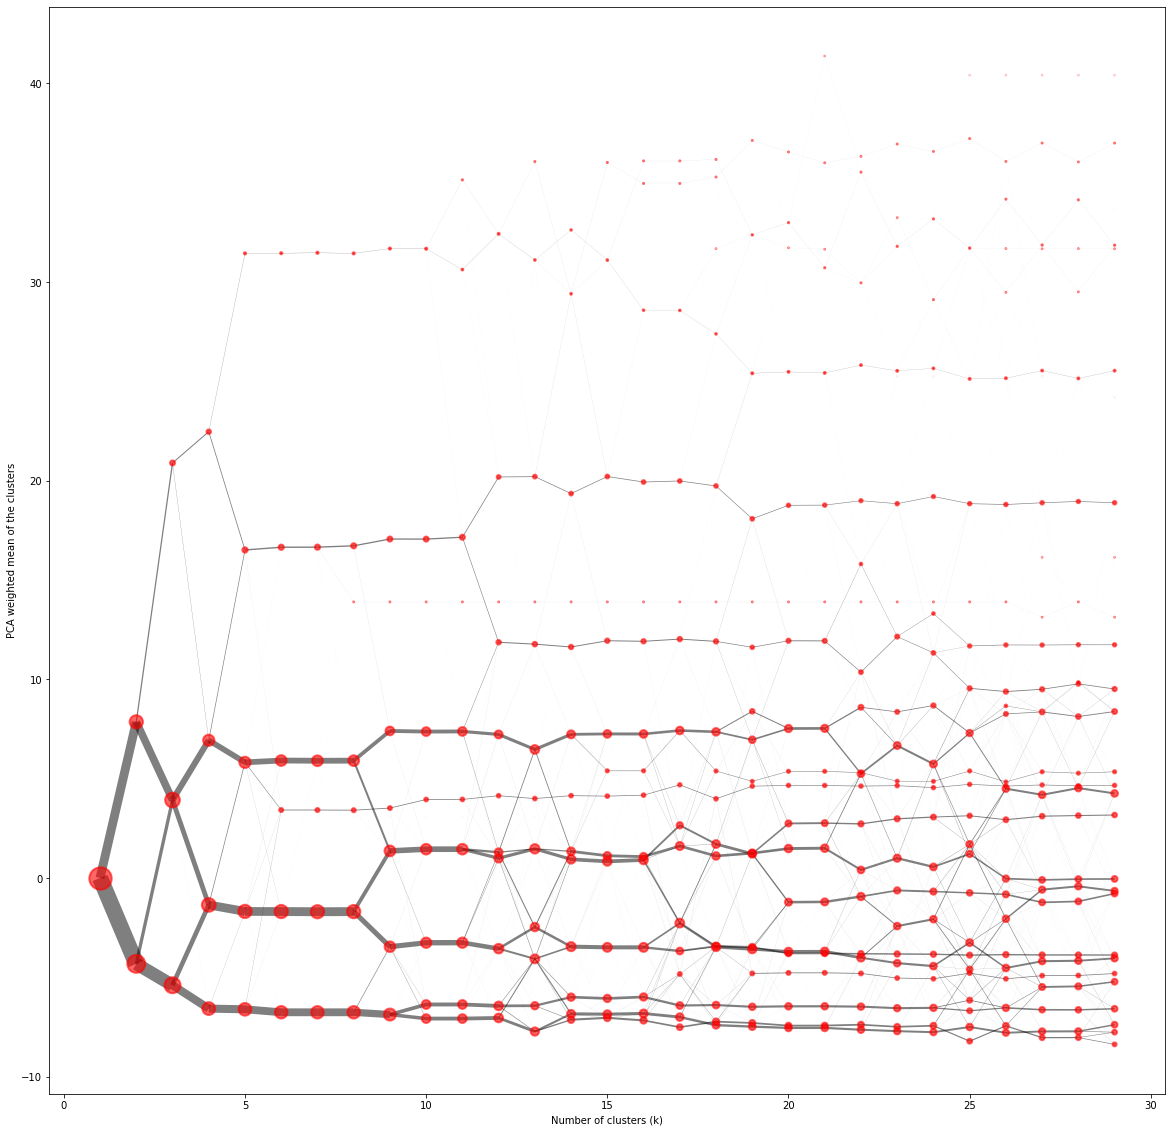

In [6]:
ax = cg_form.plot(figsize=(20, 20), linewidth=0.5, cluster_style={"edgecolor": "r", "alpha":.6}, size=1,
       line_style={"alpha":.5})

Based on the clustergram, we can assume that 13 clusters is the optimal number. 13 is the first point after all major branching happens and the situation stabilizes.

Before proceeding, we also save clustergam object to a file.

In [7]:
with open(folder + 'clustergram_form.pickle','wb') as f:
    pickle.dump(cg_form, f)

Let's see how 13 clusters based on form look like spatially.

In [8]:
%time km_form = KMeans(n_clusters=13, n_init=100).fit(data)

CPU times: user 29min 58s, sys: 11min 49s, total: 41min 48s
Wall time: 3min 51s


In [9]:
tess['clusters_form'] = km_form.labels_

We can plot the labels based on tessellation or based on buildings, each providing different insights.

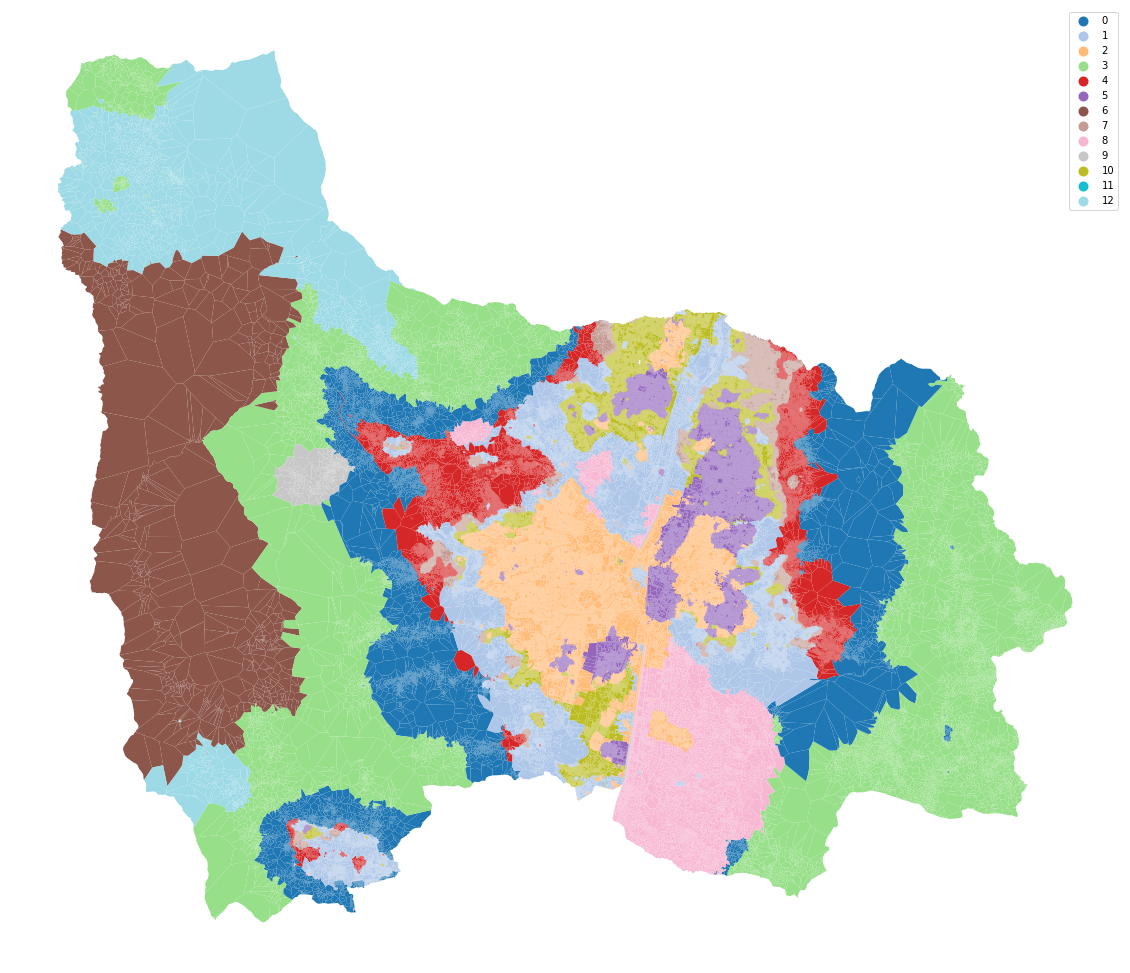

In [10]:
ax = tess.plot('clusters_form', categorical=True, legend=True, figsize=(20, 20), cmap='tab20')
ax.set_axis_off()

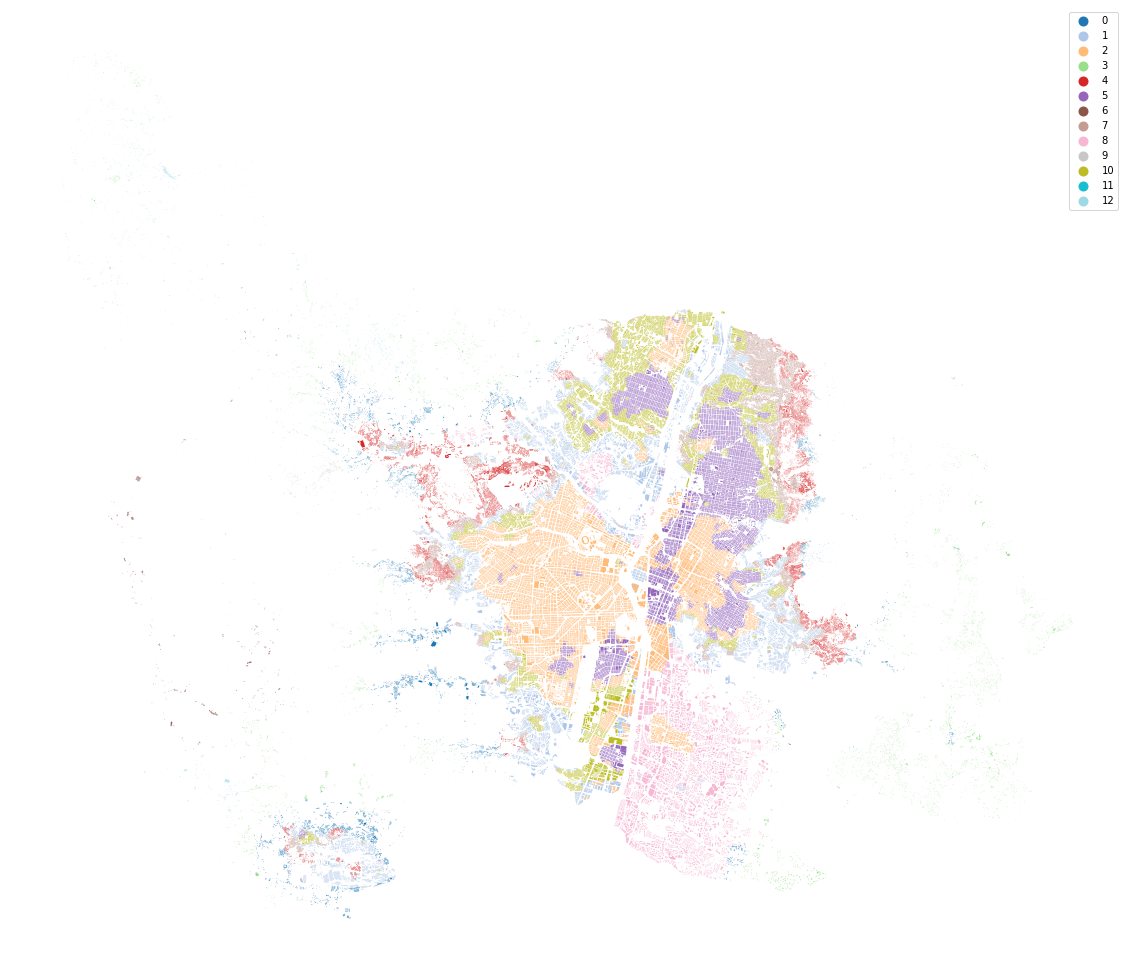

In [11]:
ax = tess.set_geometry('buildings').plot('clusters_form', categorical=True, legend=True, figsize=(20, 20), cmap='tab20')
ax.set_axis_off()

### 3.2. Function

Clustering based on function uses only data on function, which we need to prepare. We first join all data together.

In [10]:
function = pd.read_parquet(folder + "func_data_tess.pq")
function_nodes = pd.read_parquet(folder + "func_data_nodes.pq")
ndvi = pd.read_parquet(folder + "ndvi.pq")

In [11]:
function["nodeID"] = tess["nodeID"].values

In [12]:
function = function.merge(function_nodes, how='left', on='nodeID')

In [13]:
function['ndvi'] = ndvi.ndvi.values

Let's remove anything we don't want to keep only the data.

In [14]:
function_data = function[['tID', 'trees', 'heritage_area', 'AREAGRALUS', 'SUBCATEGOR',
       'public_space_distance', 'population', 'park_distance',
       'heritage', 'pois', 'commerce', 'ndvi']].set_index('tID')

In [11]:
function_data.head()

,trees,heritage_area,AREAGRALUS,SUBCATEGOR,public_space_distance,population,park_distance,heritage,pois,commerce,ndvi
tID,,,,,,,,,,,
0,0,False,Áreas y corredores de alta mixtura,Centralidades con predominancia económica,102.393901,158.489067,127.496182,0,278,10825,0.151228
1,0,False,Áreas y corredores de alta mixtura,Centralidades con predominancia económica,115.824151,157.231369,143.671397,0,278,10825,0.175213
2,0,False,Áreas y corredores de alta mixtura,Centralidades con predominancia económica,94.088581,158.495392,149.524693,0,320,11408,0.165669
3,2,False,Áreas y corredores de alta mixtura,Centralidades con predominancia económica,61.817796,159.759415,155.583779,0,314,11557,0.172687
4,0,False,Áreas y corredores de alta mixtura,Centralidades con predominancia económica,109.073899,159.746765,110.750780,0,278,10825,0.093946


We have some categorical values, so we have to encode them as boolean dummies.

In [15]:
heritage_area = pd.get_dummies(function_data.heritage_area)
AREAGRALUS = pd.get_dummies(function_data.AREAGRALUS)
SUBCATEGOR = pd.get_dummies(function_data.SUBCATEGOR)

Continuous values need to be standardized.

In [16]:
scaler = preprocessing.StandardScaler()
f_data = scaler.fit_transform(function_data.drop(columns=["heritage_area", "AREAGRALUS", "SUBCATEGOR"]))

In [14]:
f_data.shape

(337737, 8)

We can all merge back together.

In [17]:
f_data = np.hstack([f_data, heritage_area.values, AREAGRALUS.values, SUBCATEGOR.values])

In [16]:
f_data.shape

(337737, 22)

In [17]:
np.isnan(f_data).any().any()

False

We are using clustergram again.

In [38]:
cg_function = Clustergram(range(1, 30), backend='sklearn', n_init=10)
cg_function.fit(f_data)

PCA computed in 0.7089238166809082 seconds.
K=1 fitted in 0.8653995990753174 seconds.
K=2 fitted in 2.655245542526245 seconds.
K=3 fitted in 3.4039812088012695 seconds.
K=4 fitted in 3.5148792266845703 seconds.
K=5 fitted in 3.006239891052246 seconds.
K=6 fitted in 3.863337755203247 seconds.
K=7 fitted in 4.583117723464966 seconds.
K=8 fitted in 5.1925177574157715 seconds.
K=9 fitted in 6.0883471965789795 seconds.
K=10 fitted in 7.251549005508423 seconds.
K=11 fitted in 8.41685438156128 seconds.
K=12 fitted in 9.140989065170288 seconds.
K=13 fitted in 10.529053449630737 seconds.
K=14 fitted in 9.76606297492981 seconds.
K=15 fitted in 10.070903301239014 seconds.
K=16 fitted in 13.229736089706421 seconds.
K=17 fitted in 14.566571950912476 seconds.
K=18 fitted in 12.859219789505005 seconds.
K=19 fitted in 16.9245183467865 seconds.
K=20 fitted in 14.545100927352905 seconds.
K=21 fitted in 15.227590322494507 seconds.
K=22 fitted in 25.33353614807129 seconds.
K=23 fitted in 21.03563117980957

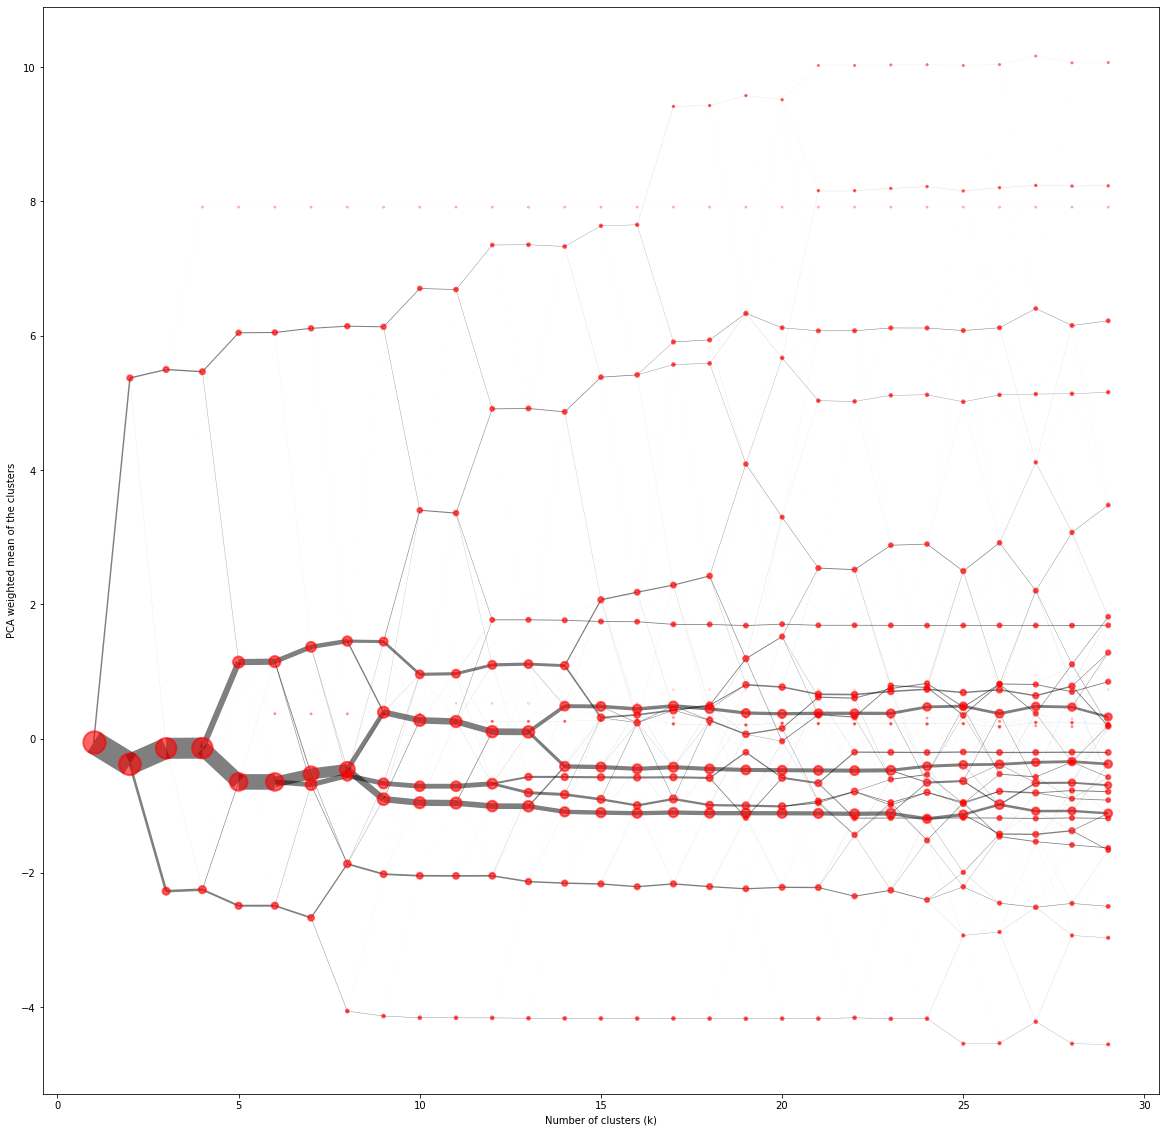

In [39]:
ax = cg_function.plot(figsize=(20, 20), linewidth=0.5, cluster_style={"edgecolor": "r", "alpha":.6}, size=1,
       line_style={"alpha":.5})

Clustergram should be saved to a file.

In [40]:
with open(folder + 'clustergram_function.pickle','wb') as f:
    pickle.dump(cg_function, f)

We can interpret the diagram as 10 clusters being the optimum.

The figures below show 10 clusters.

In [41]:
km_function = KMeans(n_clusters=10, n_init=100).fit(f_data)

In [42]:
tess['clusters_function'] = km_function.labels_

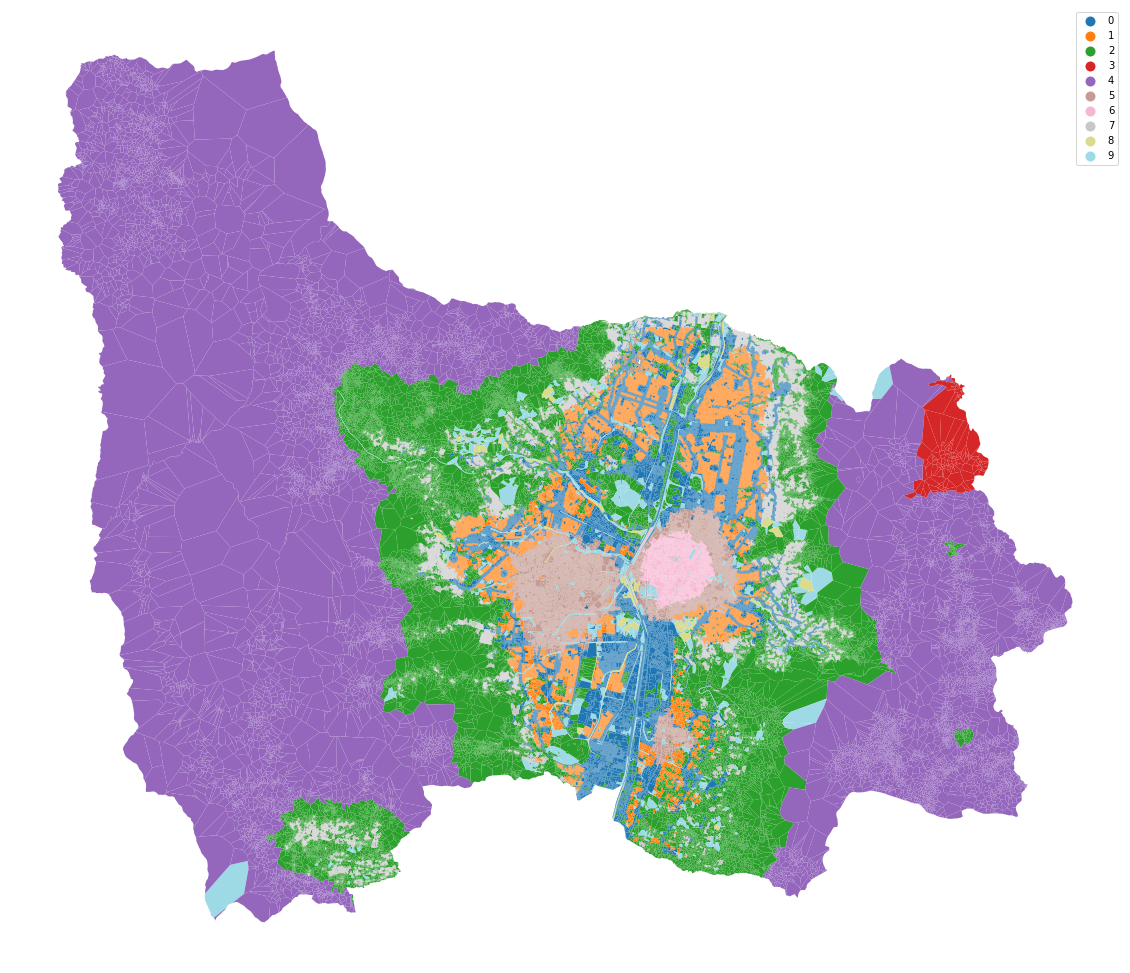

In [43]:
ax = tess.plot('clusters_function', categorical=True, legend=True, figsize=(20, 20), cmap='tab20')
ax.set_axis_off()

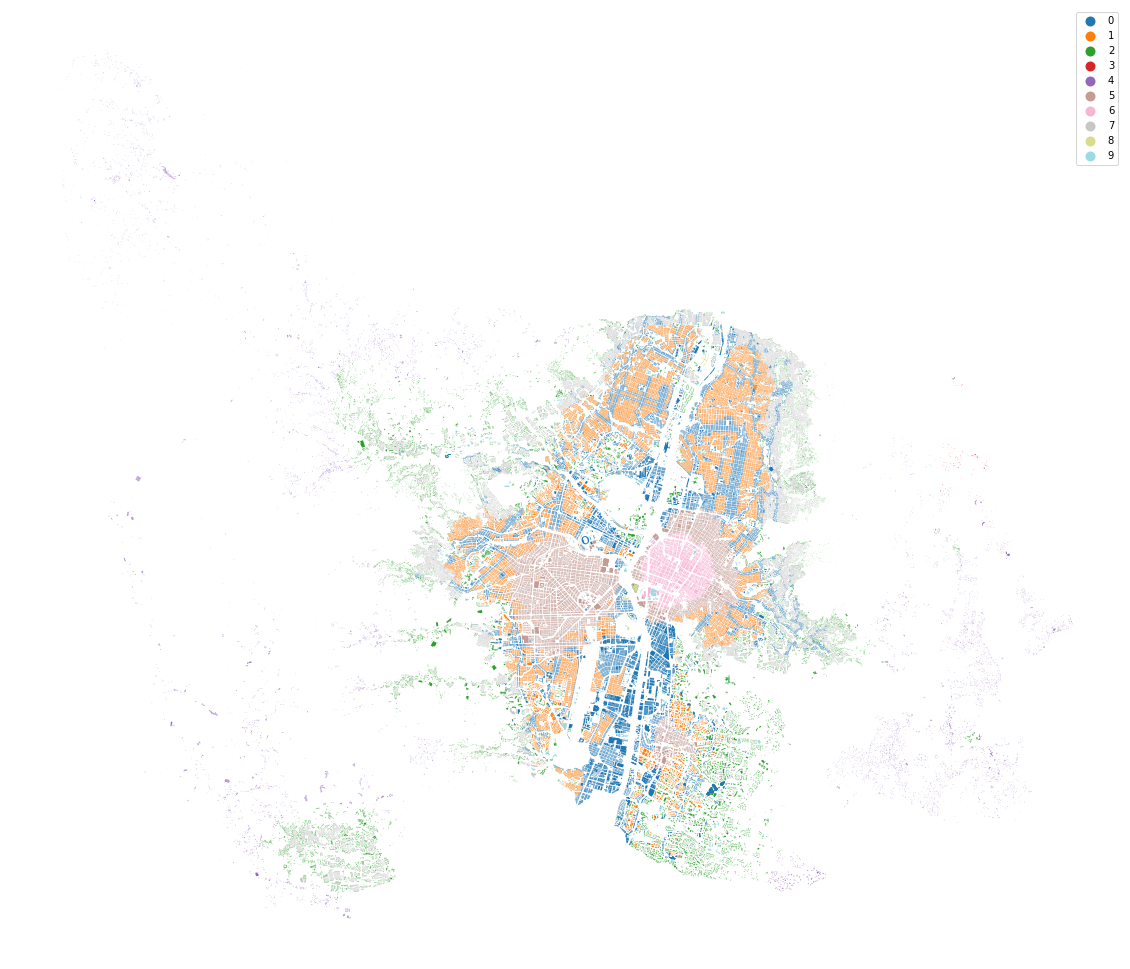

In [44]:
ax = tess.set_geometry('buildings').plot('clusters_function', categorical=True, legend=True, figsize=(20, 20), cmap='tab20')
ax.set_axis_off()

### 3.3. Spatial Signatures

Final clustering combines both form and function into a singular classification.

First we stack both preprocessed arrays together and then run clustergram.

In [18]:
ss_data = np.hstack([data, f_data])

In [19]:
cg_ss = Clustergram(range(1, 30), backend='sklearn', n_init=10, random_state=0)
cg_ss.fit(ss_data)

K=1 skipped. Mean computed from data directly.
K=2 fitted in 5.042175054550171 seconds.
K=3 fitted in 8.011692523956299 seconds.
K=4 fitted in 7.880380153656006 seconds.
K=5 fitted in 10.06858205795288 seconds.
K=6 fitted in 12.97394061088562 seconds.
K=7 fitted in 16.004880666732788 seconds.
K=8 fitted in 17.960091829299927 seconds.
K=9 fitted in 18.439619779586792 seconds.
K=10 fitted in 20.85565710067749 seconds.
K=11 fitted in 23.783952951431274 seconds.
K=12 fitted in 25.389522552490234 seconds.
K=13 fitted in 26.22016978263855 seconds.
K=14 fitted in 29.075758695602417 seconds.
K=15 fitted in 42.64415693283081 seconds.
K=16 fitted in 44.169344425201416 seconds.
K=17 fitted in 39.78989386558533 seconds.
K=18 fitted in 47.01698088645935 seconds.
K=19 fitted in 57.81924772262573 seconds.
K=20 fitted in 62.265267848968506 seconds.
K=21 fitted in 53.77802658081055 seconds.
K=22 fitted in 55.886427879333496 seconds.
K=23 fitted in 62.18732833862305 seconds.
K=24 fitted in 67.7924792766

In [20]:
c = ugg.COLORS

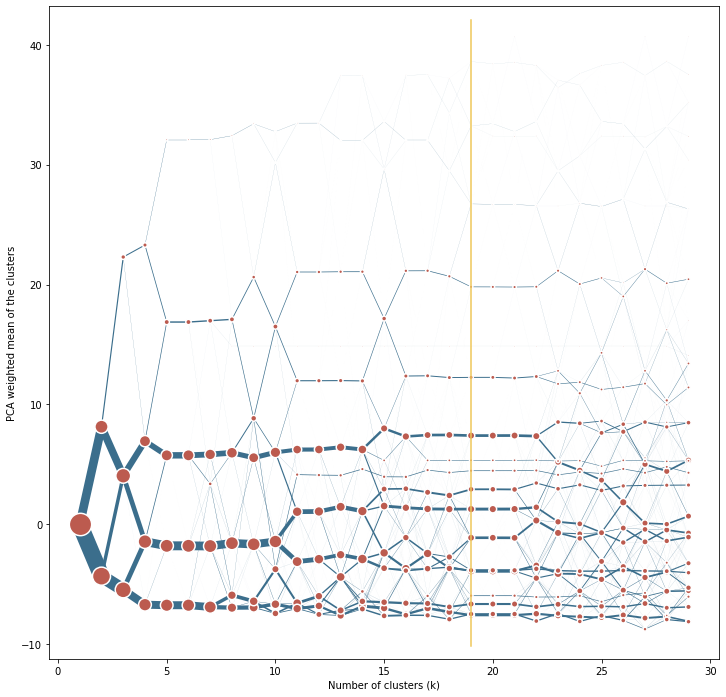

In [25]:
ax = cg_ss.plot(
    figsize=(12, 12),
    linewidth=0.5,
    cluster_style={"edgecolor": "w", "color": c[2], "linewidth": 1.5},
    size=1,
    line_style={"color":c[1]},
    pca_kwargs=dict(random_state=0),
)
ax.axvline(19, color=c[4], ymin=.02, ymax=.98)
plt.savefig(folder + "cgram.png", dpi=300, bbox_inches="tight")

In [26]:
cg_labels = cg_ss.labels
cg_labels.columns = cg_labels.columns.astype(str)
cg_labels.to_parquet(folder + 'clustergram_ss_labels.pq')

The optimal number in this case seems to be 19 clusters. We run final clustering with 1000 initiazations and fixed random state for reproducibility.

In [33]:
%time km = KMeans(n_clusters=19, n_init=1000, random_state=12345).fit(ss_data)

CPU times: user 9h 5min 36s, sys: 3h 4min 6s, total: 12h 9min 43s
Wall time: 1h 11min 16s


In [34]:
tess['clusters'] = km.labels_

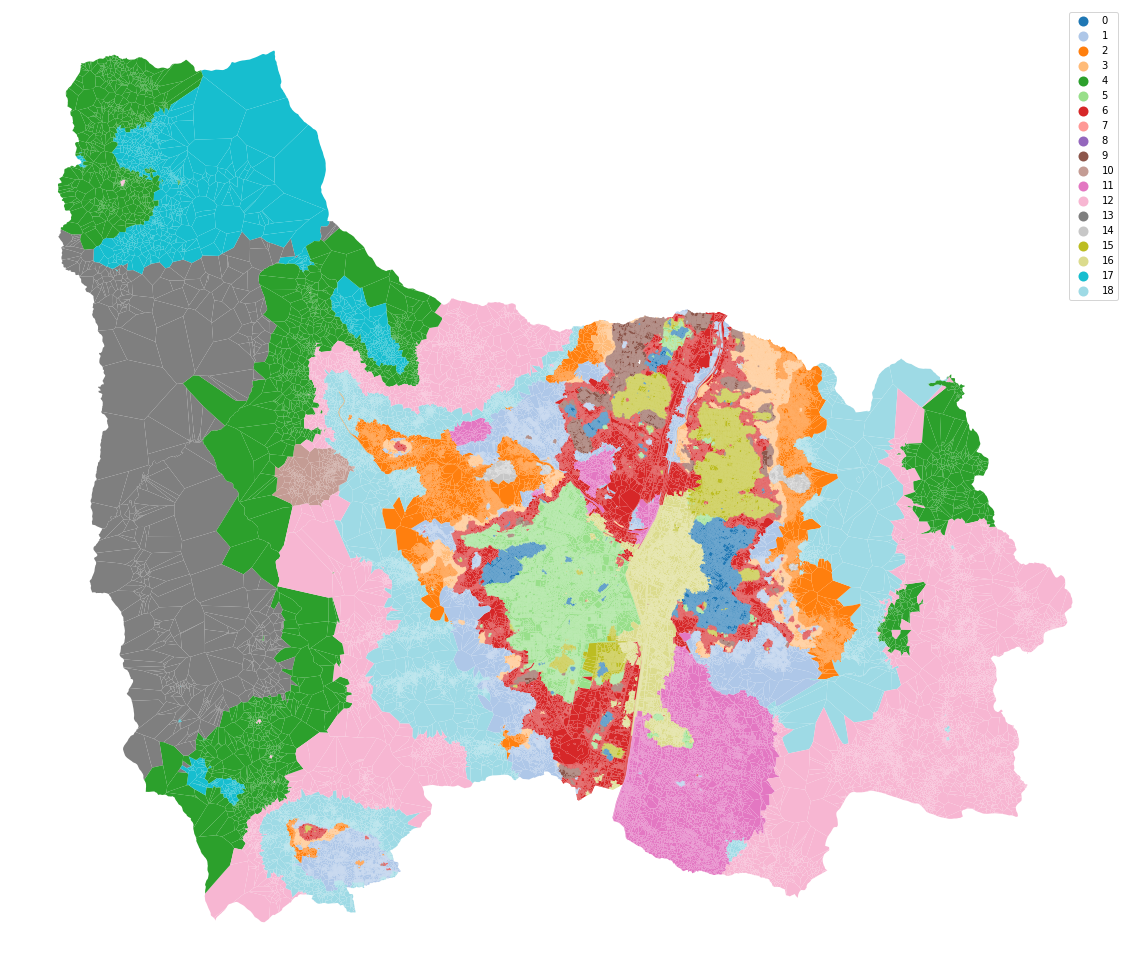

In [37]:
ax = tess.plot('clusters', categorical=True, legend=True, figsize=(20, 20), cmap='tab20')
ax.set_axis_off()

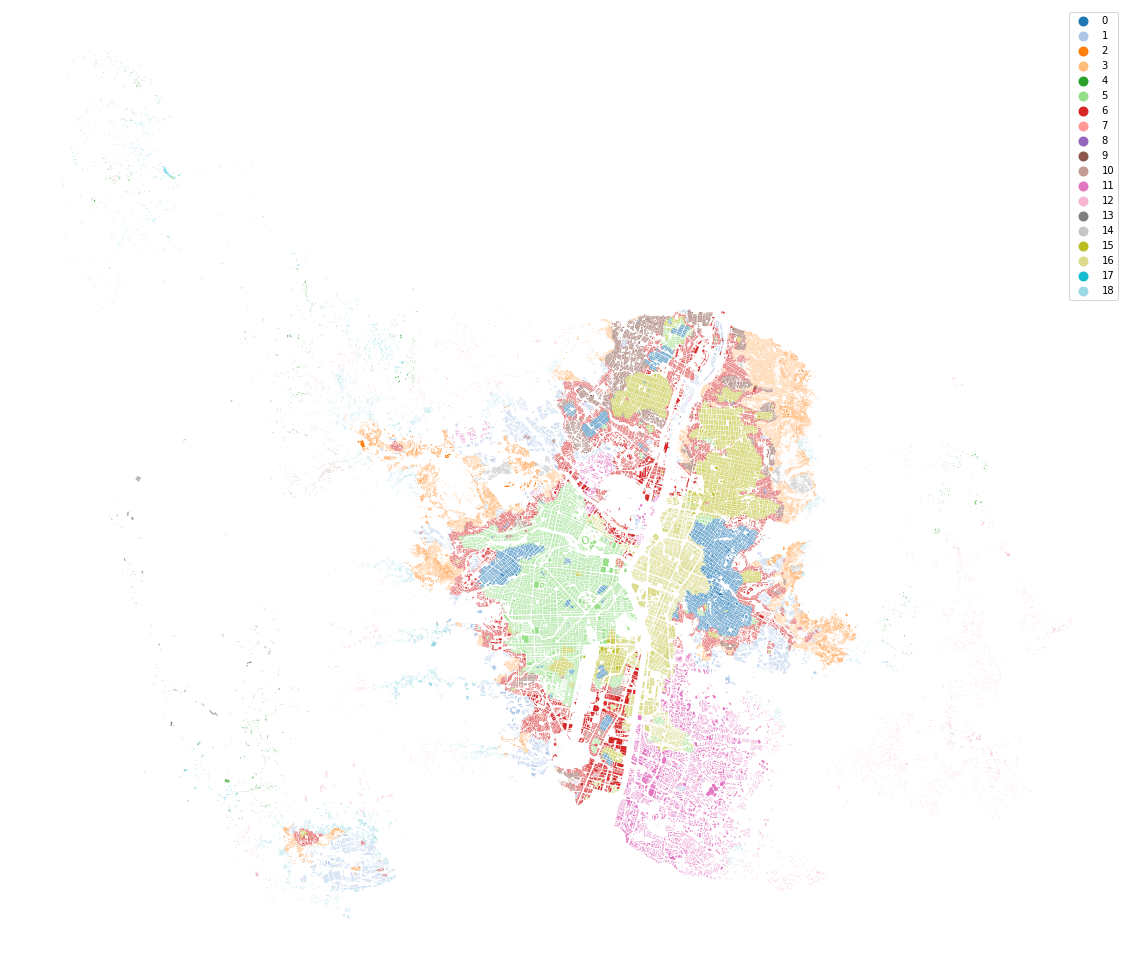

In [35]:
ax = tess.set_geometry('buildings').plot("clusters", categorical=True, legend=True, figsize=(20, 20), cmap='tab20')
ax.set_axis_off()

In [54]:
tess[['tID', 'clusters', 'clusters_form', 'clusters_function']].to_parquet(folder + "cluster_labels.pq")

In [36]:
tess[['tID', 'clusters']].to_parquet(folder + "FINAL_cluster_19_labels.pq")

#### Generate signatures

As a final step, we can generate a geometry representing spatial singatures as a combination of contiguous tessellation cells belonging to a single cluster. Since we have to dissolve a large number of polygons, we use dask_geopandas to parallelize the procedure.

First we create a local cluster.

In [3]:
client = Client(LocalCluster(n_workers=16))
client

/opt/conda/lib/python3.8/site-packages/distributed/node.py:151: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46555 instead
  warnings.warn(


Client Scheduler: tcp://127.0.0.1:39749 Dashboard: http://127.0.0.1:46555/status,Cluster Workers: 16 Cores: 16 Memory: 134.91 GB


We read only 'tessellation' columns and cluster labels. The resulting geometry will not be enclosed tessellation anymore so we can already rename it to generic "geometry".

In [4]:
tess = gpd.read_parquet(folder + "tess.pq", columns=['tessellation']).rename_geometry("geometry")
clusters = pd.read_parquet(folder + "FINAL_cluster_19_labels.pq")

In [5]:
tess['cluster'] = clusters.clusters.values

`dask_dissolve` mimics the behaviour of `geopandas.dissolve`, just based on parallel implementation using `dask-geopandas`.

In [6]:
%%time
ddf = dask_geopandas.from_geopandas(tess.sort_values('cluster'), npartitions=64)
final = dask_dissolve(ddf, by='cluster').compute()

/opt/conda/lib/python3.8/site-packages/dask_geopandas/backends.py:31: FutureWarning: The input object of type 'LineString' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'LineString', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  a = np.array(


CPU times: user 19.5 s, sys: 4.4 s, total: 23.9 s
Wall time: 1min 23s


<AxesSubplot:>

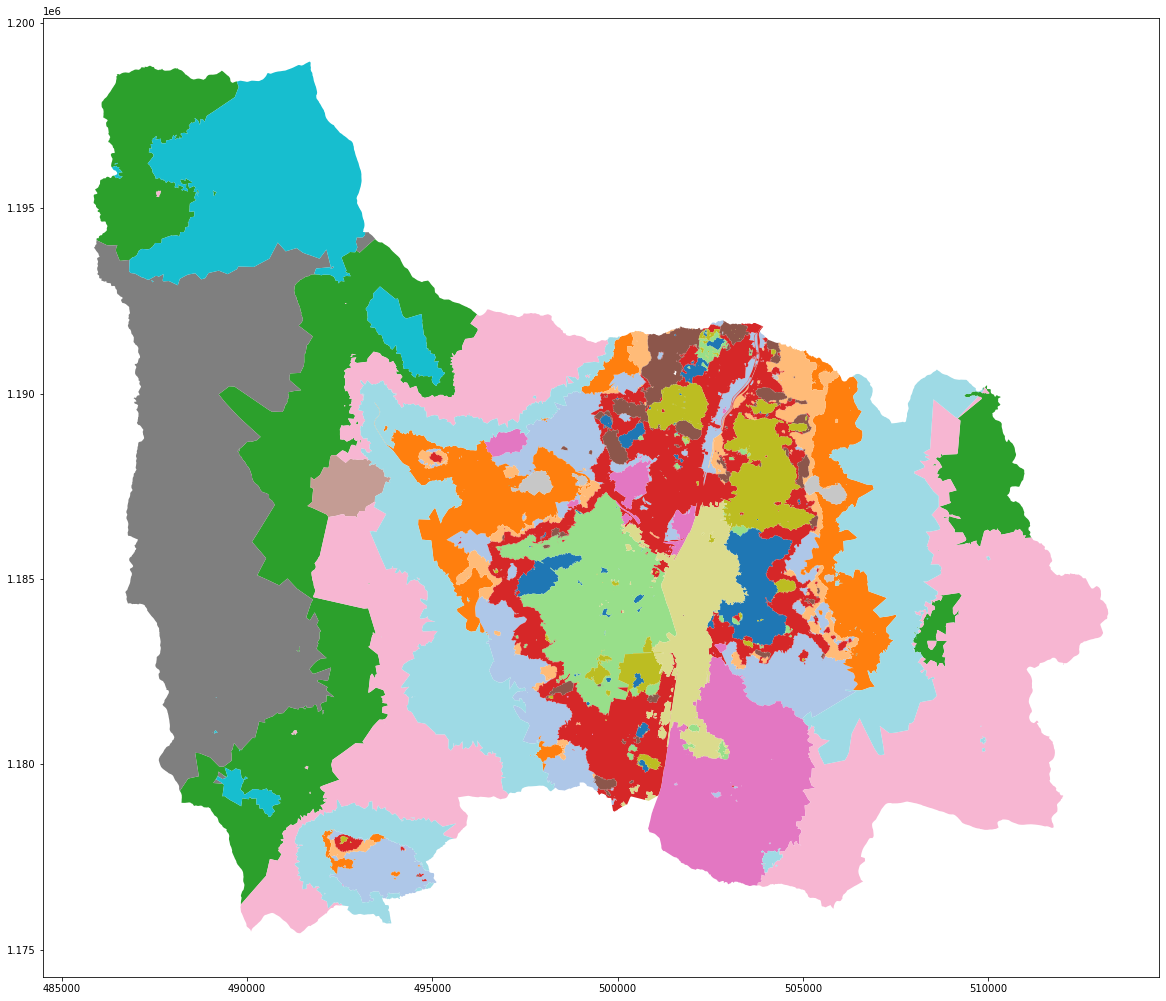

In [7]:
final.plot('cluster', categorical=True, figsize=(20, 20), cmap='tab20')

Finally, we explode the geometries to get multiple singatures of the same kind instead of a single multipolygon. (The intial `reset_index` is here to avoid bug in geopandas.)

In [8]:
final.reset_index(drop=True).explode().reset_index(drop=True).to_parquet(folder + "signatures.pq")

<ipython-input-8-1c51f5ab0c27>:1: UserWarning: this is an initial implementation of Parquet/Feather file support and associated metadata.  This is tracking version 0.1.0 of the metadata specification at https://github.com/geopandas/geo-arrow-spec

This metadata specification does not yet make stability promises.  We do not yet recommend using this in a production setting unless you are able to rewrite your Parquet/Feather files.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', message='.*initial implementation of Parquet.*')
  final.reset_index(drop=True).explode().reset_index(drop=True).to_parquet(folder + "signatures.pq")


Before we end, we close dask client.

In [10]:
client.close()

## 4. Figures

Finally, we create final figures.

In [3]:
final = gpd.read_parquet(folder + "signatures.pq")

In [4]:
enc = gpd.read_parquet(folder + "enclosures.pq")

In [3]:
sns.set(context="paper", style="ticks", rc={'patch.force_edgecolor': False})

In [8]:
cmap = ugg.get_colormap(final.cluster.nunique(), randomize=False)

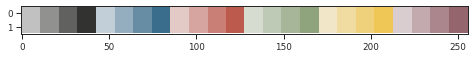

In [9]:
gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))

fig, ax = plt.subplots(figsize=(8, .5))
ax.imshow(gradient, aspect='auto', cmap=cmap)

<AxesSubplot:>

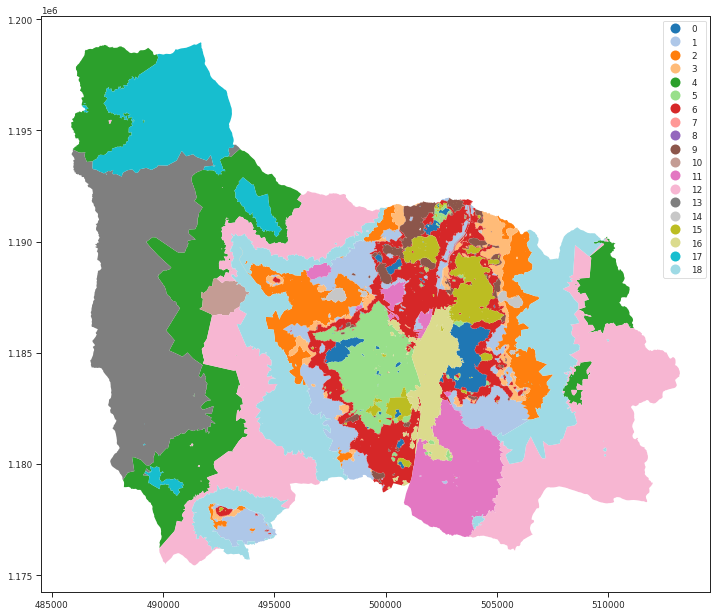

In [12]:
final.plot('cluster', cmap='tab20', legend=True, figsize=(12, 12), categorical=True)

In [5]:
cols = cmap.colors
symbology = {0: cols[19],
             1: cols[4],
             2: cols[23],
             3: cols[8],
             4: cols[1],
             5: cols[11],
             6: cols[15],
             7: cols[17],
             8: cols[6],
             9: cols[5],
             10: cols[18],
             11: cols[10],
             12: cols[9],
             13: cols[12],
             14: cols[16],
             15: cols[21],
             16: cols[7],
             17: cols[0],
             18: cols[13],
            }

In [14]:
df = final.set_crs(enc.crs).to_crs(3857)

In [15]:
token = ""

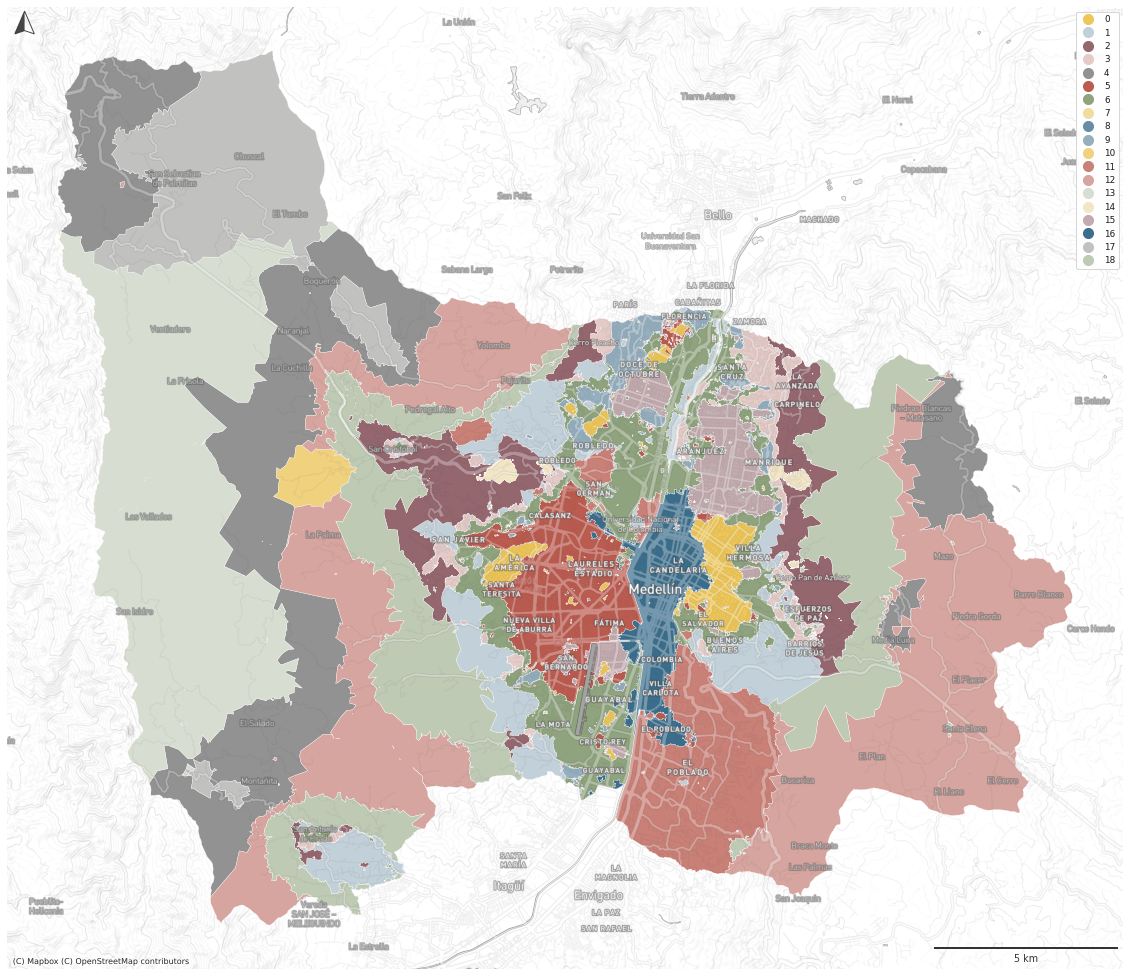

In [27]:
ax = df.plot(color=df['cluster'].map(symbology), figsize=(20, 20), zorder=1, linewidth=.3, edgecolor='w', alpha=1)
contextily.add_basemap(ax, crs=df.crs, source=ugg.get_tiles('roads', token), zorder=2, alpha=.3, zoom=13)
contextily.add_basemap(ax, crs=df.crs, source=ugg.get_tiles('labels', token), zorder=3, alpha=1, zoom=13)
contextily.add_basemap(ax, crs=df.crs, source=ugg.get_tiles('background', token), zorder=-1, alpha=1, zoom=13)
ax.set_axis_off()

scalebar = ScaleBar(dx=1,
                    color=ugg.COLORS[0],
                    location='lower right',
                    height_fraction=0.002,
                    pad=.5,
                    frameon=False,
                    )
ax.add_artist(scalebar)

ugg.north_arrow(plt.gcf(), ax, 0, size=.026, linewidth=1, color=ugg.COLORS[0], loc="upper left", pad=.002, alpha=.9)

from matplotlib.lines import Line2D
custom_points = [Line2D([0], [0], marker="o", linestyle="none", markersize=10, color=color) for color in symbology.values()]
leg_points = ax.legend(custom_points, symbology.keys(), loc='upper right', frameon=True)
ax.add_artist(leg_points)
plt.savefig(folder + "signatures.png", dpi=300, bbox_inches="tight")

In [28]:
tess = gpd.read_parquet(folder + "tess.pq").set_geometry('buildings')
clusters = pd.read_parquet(folder + "FINAL_cluster_19_labels.pq")
tess['cluster'] = clusters.clusters.values

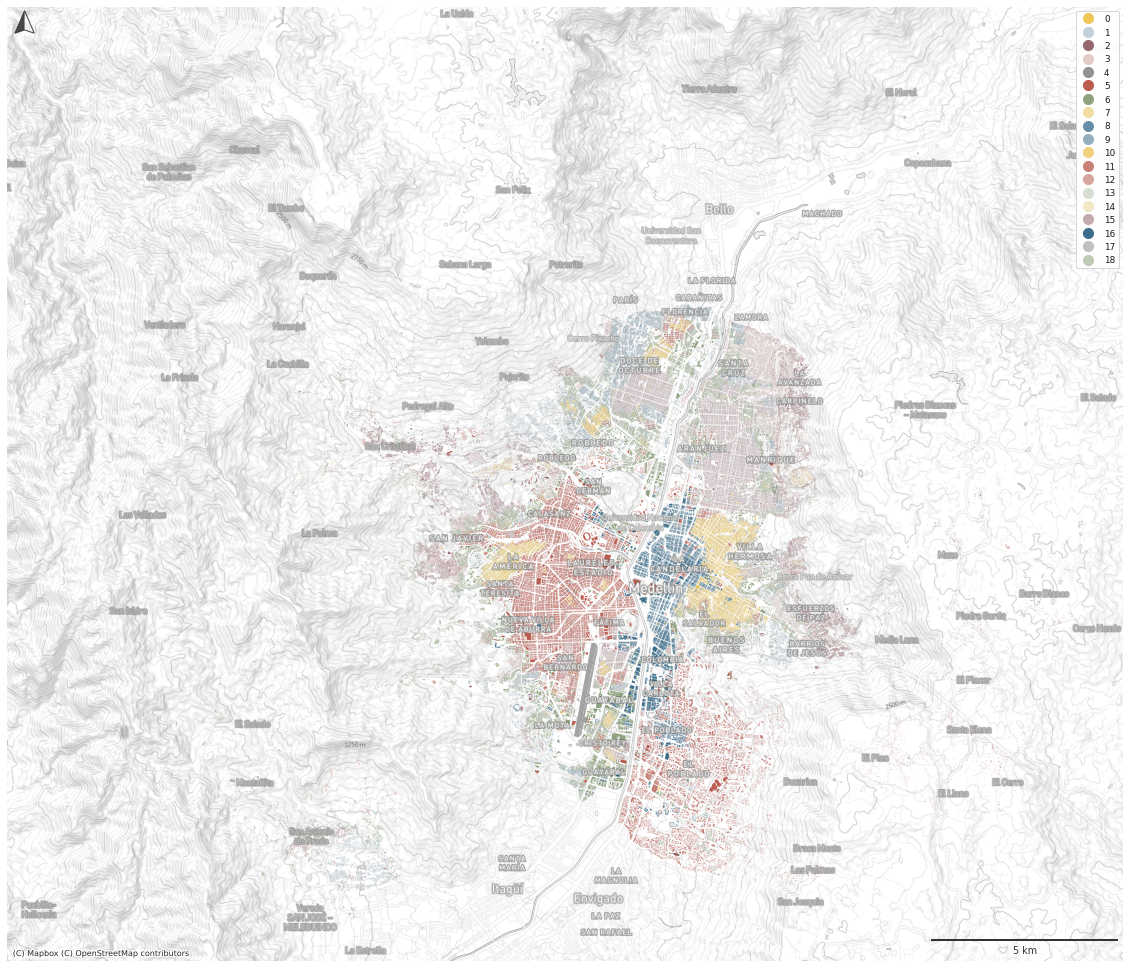

In [29]:
ax = tess.to_crs(3857).plot(color=tess['cluster'].map(symbology), figsize=(20, 20), zorder=1, alpha=1)
contextily.add_basemap(ax, crs=df.crs, source=ugg.get_tiles('roads', token), zorder=2, alpha=.3, zoom=13)
contextily.add_basemap(ax, source=ugg.get_tiles('labels', token), zorder=3, alpha=1, zoom=13)
contextily.add_basemap(ax, source=ugg.get_tiles('background', token), zorder=-1, alpha=1, zoom=13)
ax.set_axis_off()

scalebar = ScaleBar(dx=1,
                    color=ugg.COLORS[0],
                    location='lower right',
                    height_fraction=0.002,
                    pad=.5,
                    frameon=False,
                    )
ax.add_artist(scalebar)

ugg.north_arrow(plt.gcf(), ax, 0, size=.026, linewidth=1, color=ugg.COLORS[0], loc="upper left", pad=.002, alpha=.9)

from matplotlib.lines import Line2D
custom_points = [Line2D([0], [0], marker="o", linestyle="none", markersize=10, color=color) for color in symbology.values()]
leg_points = ax.legend(custom_points, symbology.keys(), loc='upper right', frameon=True)
ax.add_artist(leg_points)
plt.savefig(folder + "signatures_buildings.png", dpi=300, bbox_inches="tight")

In [6]:
clusters = pd.read_parquet(folder + "FINAL_cluster_19_labels.pq")

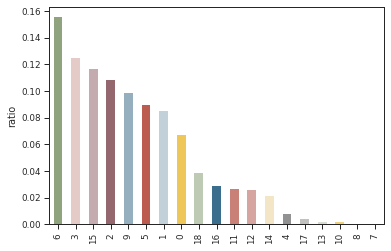

In [8]:
counts = clusters.clusters.value_counts(normalize=True)
color = counts.index.map(symbology)
counts.plot.bar(color=color)
plt.ylabel("ratio")
plt.savefig(folder + "counts.pdf", dpi=300, bbox_inches="tight")

## Cluster summary

We can also export summary values of our input characters for each cluster.

In [3]:
data = gpd.read_parquet(folder + "data.pq")

We list characters we want to summarise.

In [7]:
characters = [
    "stcOri",
    "stbOri",
    "stbCeA",
    "sdcLAL",
    "sdcAre",
    "sscCCo",
    "sscERI",
    "sicCAR",
    "mtbAli",
    "mtbNDi",
    "mtcWNe",
    "mdcAre",
    "ltbIBD",
    "stcSAl",
    "ltcWRE",
    "sdbAre",
    "sdbPer",
    "sdbCoA",
    "ssbCCo",
    "ssbCor",
    "ssbSqu",
    "ssbERI",
    "ssbElo",
    "ssbCCM",
    "ssbCCD",
    "mtbSWR",
    "ldbPWL",
    "stbSAl",
    "libNCo",
    "sdsLen",
    "sdsSPW",
    "sdsSPO",
    "sdsSWD",
    "sssLin",
    "sdsAre",
    "sisBpM",
    "misRea",
    "mdsAre",
    "ldsMSL",
    "degree",
    "meshedness",
    "proportion_3",
    "proportion_4",
    "proportion_0",
    "local_closeness",
    "ldsCDL",
    "xcnSCl",
    "mtdMDi",
    "lddNDe",
    "linWID",
    "sddAre",
    "ldeAre",
    "ldePer",
    "lseCCo",
    "lseERI",
    "lseCWA",
    "lteOri",
    "lteWNB",
    "lieWCe",
]

In [9]:
clusters = pd.read_parquet(folder + "FINAL_cluster_19_labels.pq")

In [10]:
data["cluster"] = clusters.clusters.values

We get mean of each character for each cluster.

In [11]:
means = data[characters].groupby(data.cluster).mean().T

It is better to use full names as the result should be interpretable. Codes are not that useful.

In [12]:
char_names = {
    'sdbAre': 'area of building',
    'sdbPer': 'perimeter of building',
    'sdbCoA': 'courtyard area of building',
    'ssbCCo': 'circular compactness of building',
    'ssbCor': 'corners of building',
    'ssbSqu': 'squareness of building',
    'ssbERI': 'equivalent rectangular index of building',
    'ssbElo': 'elongation of building',
    'ssbCCM': 'centroid - corner mean distance of building',
    'ssbCCD': 'centroid - corner distance deviation of building',
    'stbOri': 'orientation of building',
    'sdcLAL': 'longest axis length of ETC',
    'sdcAre': 'area of ETC',
    'sscCCo': 'circular compactness of ETC',
    'sscERI': 'equivalent rectangular index of ETC',
    'stcOri': 'orientation of ETC',
    'sicCAR': 'covered area ratio of ETC',
    'stbCeA': 'cell alignment of building',
    'mtbAli': 'alignment of neighbouring buildings',
    'mtbNDi': 'mean distance between neighbouring buildings',
    'mtcWNe': 'perimeter-weighted neighbours of ETC',
    'mdcAre': 'area covered by neighbouring cells',
    'ltcWRE': 'weighted reached enclosures of ETC',
    'ltbIBD': 'mean inter-building distance',
    'sdsSPW': 'width of street profile',
    'sdsSWD': 'width deviation of street profile',
    'sdsSPO': 'openness of street profile',
    'sdsLen': 'length of street segment',
    'sssLin': 'linearity of street segment',
    'ldsMSL': 'mean segment length within 3 steps',
    'degree': 'node degree of junction',
    'meshedness': 'local meshedness of street network',
    'proportion_3': 'local proportion of 3-way intersections of street network',
    'proportion_4': 'local proportion of 4-way intersections of street network',
    'proportion_0': 'local proportion of cul-de-sacs of street network',
    'local_closeness': 'local closeness of street network',
    'ldsCDL': 'local cul-de-sac length of street network',
    'xcnSCl': 'square clustering of street network',
    'mtdMDi': 'mean distance to neighbouring nodes of street network',
    'lddNDe': 'local node density of street network',
    'linWID': 'local degree weighted node density of street network',
    'stbSAl': 'street alignment of building',
    'stcSAl': 'street alignment of ETC',
    'mtbSWR': 'shared walls ratio of buildings',
    'sddAre': 'area covered by node-attached ETCs',
    'sdsAre': 'area covered by edge-attached ETCs',
    'sisBpM': 'buildings per meter of street segment',
    'misCel': 'reached ETCs by neighbouring segments',
    'mdsAre': 'reached area by neighbouring segments',
    'lisCel': 'reached ETCs by local street network',
    'ldsAre': 'reached area by local street network',
    'ltcRea': 'reached ETCs by tessellation contiguity',
    'ltcAre': 'reached area by tessellation contiguity',
    'ldeAre': 'area of enclosure',
    'ldePer': 'perimeter of enclosure',
    'lseCCo': 'circular compactness of enclosure',
    'lseERI': 'equivalent rectangular index of enclosure',
    'lseCWA': 'compactness-weighted axis of enclosure',
    'lteOri': 'orientation of enclosure',
    'lteWNB': 'perimeter-weighted neighbours of enclosure',
    'lieWCe': 'area-weighted ETCs of enclosure',
    'ldbPWL': 'perimeter wall length of adjacent buildings',
    'libNCo': 'number of courtyards within adjacent buildings',
    'misRea': 'cells reached within neighbouring street segments'
}

In [13]:
means.index = means.index.map(char_names)

We do the same with function characters.

In [17]:
function = pd.read_parquet(folder + "func_data_tess.pq")
function_nodes = pd.read_parquet(folder + "func_data_nodes.pq")
ndvi = pd.read_parquet(folder + "ndvi.pq")

In [18]:
tess = gpd.read_parquet(folder + "tess.pq")
function["nodeID"] = tess["nodeID"].values

In [19]:
function = function.merge(function_nodes, how='left', on='nodeID')

In [20]:
function['ndvi'] = ndvi.ndvi.values

In [27]:
function_data = function[['tID', 'trees',
       'public_space_distance', 'population', 'park_distance',
        'pois', 'commerce', 'ndvi']].set_index('tID')

In [28]:
f_means = function_data.groupby(data.cluster.values).mean().T

In [29]:
f_means.index = ["trees", "public spaces", "population", "parks", "points of interest", "commercial points of interest", "NDVI"]

Finally, we join form and function summaries and plot the final output as a styled pandas DataFrame.

In [30]:
together = means.append(f_means)

In [32]:
together.fillna(0).style.format('{:.2f}').background_gradient(cmap=sns.diverging_palette(235, 16, 60, 55, as_cmap=True) ,axis=1,)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
orientation of ETC,32.00,21.22,21.91,20.44,22.40,14.40,21.99,0.08,23.14,18.94,22.32,20.54,22.23,21.99,21.34,12.63,20.93,23.06,20.86
orientation of building,32.58,21.03,21.23,19.79,20.77,13.67,21.74,0.00,0.00,18.69,19.94,19.45,20.14,22.39,20.78,11.81,20.86,23.43,19.65
cell alignment of building,2.89,4.49,8.71,5.96,14.28,3.08,4.41,0.00,0.00,3.00,12.82,8.92,13.87,14.26,8.47,2.69,2.47,13.44,10.02
longest axis length of ETC,29.06,31.96,27.33,19.39,187.90,35.41,31.03,0.04,1.52,18.76,95.69,70.50,116.55,384.46,21.50,26.73,52.02,151.06,60.84
area of ETC,249.54,681.05,505.88,155.22,20749.24,460.31,447.06,0.00,0.00,139.88,4753.46,2079.54,8259.09,80795.86,191.56,206.73,885.19,18840.75,3424.38
circular compactness of ETC,0.36,0.41,0.46,0.44,0.39,0.39,0.38,0.23,0.07,0.43,0.40,0.45,0.42,0.31,0.40,0.35,0.37,0.40,0.42
equivalent rectangular index of ETC,0.92,0.93,0.94,0.93,0.95,0.92,0.93,0.86,0.87,0.94,0.95,0.95,0.96,0.88,0.58,0.92,0.93,0.96,0.95
covered area ratio of ETC,0.57,3.19,0.87,3.01,0.03,0.54,0.66,0.00,0.00,0.63,0.09,0.28,0.05,0.02,0.62,0.56,0.59,0.05,0.24
alignment of neighbouring buildings,1.60,3.13,7.80,6.20,12.47,1.87,3.30,0.00,0.00,1.78,11.26,8.01,11.38,12.45,7.58,1.16,2.09,12.01,8.43
mean distance between neighbouring buildings,2.64,9.08,8.69,3.47,98.74,3.91,5.35,0.00,0.00,2.29,45.92,21.85,56.91,215.57,5.28,2.62,5.02,79.46,25.87


## Create a data product

Create files to be uploaded to figshare for public access. We need the raw measured data on ET level and signature geometry.

In [5]:
form = gpd.read_parquet(folder + "data.pq")
conv = pd.read_parquet(folder + "convolutions.pq")

In [6]:
function = pd.read_parquet(folder + "func_data_tess.pq")
function_nodes = pd.read_parquet(folder + "func_data_nodes.pq")
ndvi = pd.read_parquet(folder + "ndvi.pq")

tess = gpd.read_parquet(folder + "tess.pq")
function["nodeID"] = tess["nodeID"].values

function = function.merge(function_nodes, how='left', on='nodeID')

function['ndvi'] = ndvi.ndvi.values

function_data = function[['tID', 'trees',
       'public_space_distance', 'population', 'park_distance',
        'pois', 'commerce', 'ndvi']].set_index('tID')

In [10]:
combined = pd.concat([form, conv, function_data], axis=1)

In [19]:
clusters = pd.read_parquet(folder + "FINAL_cluster_19_labels.pq")

In [20]:
combined["signature_type"] = clusters.clusters.values

In [21]:
combined.to_parquet(folder + "medellin_data.parquet")

/tmp/ipykernel_421446/391603085.py:1: UserWarning: this is an initial implementation of Parquet/Feather file support and associated metadata.  This is tracking version 0.1.0 of the metadata specification at https://github.com/geopandas/geo-arrow-spec

This metadata specification does not yet make stability promises.  We do not yet recommend using this in a production setting unless you are able to rewrite your Parquet/Feather files.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', message='.*initial implementation of Parquet.*')
  combined.to_parquet(folder + "medellin_data.parquet")


In [12]:
sig = gpd.read_parquet(folder + "signatures.pq")

In [14]:
sig.crs = combined.crs

In [23]:
sig = sig.rename(columns={"cluster":"signature_type"})

In [24]:
sig.to_parquet(folder + "signatures.pq")

/tmp/ipykernel_421446/2073507677.py:1: UserWarning: this is an initial implementation of Parquet/Feather file support and associated metadata.  This is tracking version 0.1.0 of the metadata specification at https://github.com/geopandas/geo-arrow-spec

This metadata specification does not yet make stability promises.  We do not yet recommend using this in a production setting unless you are able to rewrite your Parquet/Feather files.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', message='.*initial implementation of Parquet.*')
  sig.to_parquet(folder + "signatures.pq")
